In [1]:
import sys
!{sys.executable} -m pip install wfdb pandas==2.2.2 numpy==1.26.4 tqdm scikit-learn

In [3]:
import sys, platform
import pandas as pd, numpy as np
import wfdb
import torch

print("python:", sys.version)
print("platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("wfdb:", wfdb.__version__)
print("torch:", torch.__version__)

python: 3.9.25 (main, Nov  3 2025, 22:29:32) 
[Clang 20.1.8 ]
platform: macOS-26.3.1-arm64-arm-64bit
pandas: 2.2.2
numpy: 1.26.4
wfdb: 4.1.2
torch: 2.8.0


In [4]:
import os, ast, math
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ========= 路径：你最终要把PTB-XL解压到这个目录 =========
PTBXL_DIR = "/Users/hedychou/Desktop/MScDS/Research/Datasets/ptbxl"

# ========= 任务设置（按你论文：100Hz + 10s=1000点 + Lead II）=========
FS = 100
SIGLEN = 1000
LEAD_IDX = 1          # Lead II
NUM_CLASSES = 2       # Normal vs Anomalous

# ========= 联邦设置 =========
NUM_CLIENTS = 10
NUM_WORKERS = 2       # mac一般2没问题，卡住就改0
SEED = 42

print("PTBXL_DIR:", PTBXL_DIR)
print("exists?", os.path.exists(PTBXL_DIR))

PTBXL_DIR: /Users/hedychou/Desktop/MScDS/Research/Datasets/ptbxl
exists? True


In [5]:
db_path  = os.path.join(PTBXL_DIR, "ptbxl_database.csv")
scp_path = os.path.join(PTBXL_DIR, "scp_statements.csv")

ready_csv = os.path.exists(db_path) and os.path.exists(scp_path)
ready_records100 = os.path.exists(os.path.join(PTBXL_DIR, "records100"))

print("ptbxl_database.csv:", os.path.exists(db_path))
print("scp_statements.csv:", os.path.exists(scp_path))
print("records100 dir:", ready_records100)

if not (ready_csv and ready_records100):
    print("⚠️ 数据还没就绪：请确保解压后目录包含 csv + records100/")

ptbxl_database.csv: True
scp_statements.csv: True
records100 dir: True


In [6]:
import pandas as pd, os

scp_path = os.path.join(PTBXL_DIR, "scp_statements.csv")
scp = pd.read_csv(scp_path, index_col=0)

print("scp columns:", scp.columns.tolist())
print(scp.head(3))

scp columns: ['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']
                         description  diagnostic  form  rhythm  \
NDT   non-diagnostic T abnormalities         1.0   1.0     NaN   
NST_         non-specific ST changes         1.0   1.0     NaN   
DIG                 digitalis-effect         1.0   1.0     NaN   

     diagnostic_class diagnostic_subclass  \
NDT              STTC                STTC   
NST_             STTC                NST_   
DIG              STTC                STTC   

                                     Statement Category  \
NDT                   other ST-T descriptive statements   
NST_  Basic roots for coding ST-T changes and abnorm...   
DIG                   other ST-T descriptive statements   

       SCP-ECG Statement Description  AHA code            aECG REFID  \
NDT   non-diagnostic T abnormali

In [7]:
import os
import pandas as pd

PTBXL_DIR = "/Users/hedychou/Desktop/MScDS/Research/Datasets/ptbxl"

db_path = os.path.join(PTBXL_DIR, "ptbxl_database.csv")
assert os.path.exists(db_path), f"找不到 {db_path}，检查 PTBXL_DIR"

meta = pd.read_csv(db_path)

# 100Hz路径（records100）
assert "filename_lr" in meta.columns, "ptbxl_database.csv 里没有 filename_lr"
meta["path_lr"] = meta["filename_lr"].apply(lambda p: os.path.join(PTBXL_DIR, p))

print("✅ meta loaded:", meta.shape)
print("columns sample:", meta.columns[:10].tolist())
print("example path_lr:", meta["path_lr"].iloc[0])

✅ meta loaded: (21799, 29)
columns sample: ['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date']
example path_lr: /Users/hedychou/Desktop/MScDS/Research/Datasets/ptbxl/records100/00000/00001_lr


In [8]:
import pandas as pd, ast, os

scp_path = os.path.join(PTBXL_DIR, "scp_statements.csv")
scp = pd.read_csv(scp_path, index_col=0)

scp_diag = scp[scp["diagnostic"] == 1].copy()
SUPER_COL = "diagnostic_class"

def get_classes_from_scp_codes(scp_codes_str):
    if pd.isna(scp_codes_str):
        return set()
    codes = ast.literal_eval(scp_codes_str)
    classes = set()
    for code in codes.keys():
        if code in scp_diag.index:
            c = scp_diag.loc[code, SUPER_COL]
            if isinstance(c, str) and c:
                classes.add(c)
    return classes

meta["diag_classes"] = meta["scp_codes"].apply(get_classes_from_scp_codes)
print(meta["diag_classes"].value_counts().head(10))

diag_classes
{NORM}         9069
{MI}           2532
{STTC}         2400
{CD}           1708
{MI, CD}       1297
{STTC, HYP}     781
{MI, STTC}      599
{HYP}           535
{CD, STTC}      471
{}              411
Name: count, dtype: int64


In [9]:
import ast
import pandas as pd
from sklearn.model_selection import train_test_split

# 只保留 diagnostic 类的 SCP code
diag_set = set(scp_diag.index)

def diagnostic_codes_only(scp_codes_str):
    if pd.isna(scp_codes_str):
        return set()
    codes = ast.literal_eval(scp_codes_str)
    return {c for c in codes.keys() if c in diag_set}

def binary_label_from_diag(scp_codes_str):
    """
    返回:
      0 = normal
      1 = anomalous
     -1 = 丢弃（没有明确 diagnostic 信息）
    """
    dset = diagnostic_codes_only(scp_codes_str)

    if len(dset) == 0:
        return -1   # 去掉没有明确 diagnostic 标签的样本

    if dset == {"NORM"}:
        return 0    # normal

    return 1        # 其他所有含 diagnostic abnormal code 的都算 anomalous

meta["diag_codes"] = meta["scp_codes"].apply(diagnostic_codes_only)
meta["y"] = meta["scp_codes"].apply(binary_label_from_diag).astype(int)

# 去掉不明确样本
meta = meta[meta["y"] != -1].reset_index(drop=True)

print("After filtering, records:", len(meta))
print(meta["y"].value_counts(dropna=False))
print("Anomalous rate:", meta["y"].mean())   # 这里 y=1 表示异常
print(meta.groupby("y")["diag_codes"].head(5))

After filtering, records: 21388
y
1    12319
0     9069
Name: count, dtype: int64
Anomalous rate: 0.5759771834673649
0          {NORM}
1          {NORM}
2          {NORM}
3          {NORM}
4          {NORM}
7           {IMI}
18          {NDT}
21    {NST_, DIG}
23    {NST_, DIG}
25          {LVH}
Name: diag_codes, dtype: object


In [10]:
SEED = 42

assert "strat_fold" in meta.columns, "PTB-XL meta 里没有 strat_fold"

train_df = meta[meta["strat_fold"].isin([1,2,3,4,5,6,7,8])].reset_index(drop=True)
val_df   = meta[meta["strat_fold"] == 9].reset_index(drop=True)
test_df  = meta[meta["strat_fold"] == 10].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train anomaly rate:", train_df["y"].mean())
print("Val anomaly rate:", val_df["y"].mean())
print("Test anomaly rate:", test_df["y"].mean())

Train: 17084 Val: 2146 Test: 2158
Train anomaly rate: 0.5760360571294779
Val anomaly rate: 0.5740913327120224
Test anomaly rate: 0.577386468952734


In [11]:
import numpy as np
import pandas as pd

NUM_CLIENTS = 30
SEED = 42

def assign_clients_by_patient_dirichlet(df, num_clients=10, alpha=0.3, seed=42):
    rng = np.random.default_rng(seed)

    patient_tbl = (
        df.groupby("patient_id")
          .agg(patient_label=("y", "max"))
          .reset_index()
    )

    patient_to_client = {}

    for label in sorted(patient_tbl["patient_label"].unique()):
        pats = patient_tbl.loc[patient_tbl["patient_label"] == label, "patient_id"].to_numpy()
        rng.shuffle(pats)

        props = rng.dirichlet(np.repeat(alpha, num_clients))
        raw_counts = props * len(pats)
        counts = np.floor(raw_counts).astype(int)

        remainder = len(pats) - counts.sum()
        if remainder > 0:
            frac_order = np.argsort(raw_counts - counts)[::-1]
            counts[frac_order[:remainder]] += 1

        start = 0
        for cid, cnt in enumerate(counts):
            for pid in pats[start:start + cnt]:
                patient_to_client[pid] = cid
            start += cnt

    out = df.copy()
    out["client_id"] = out["patient_id"].map(patient_to_client).astype(int)
    return out

train_df = assign_clients_by_patient_dirichlet(
    train_df,
    num_clients=NUM_CLIENTS,
    alpha=0.3,   # 想更异构就调小到 0.2 / 0.1
    seed=SEED
)

print("Clients:", train_df["client_id"].nunique())
print("Client record counts:", train_df["client_id"].value_counts().sort_index().tolist())
print("Client anomaly rates:", train_df.groupby("client_id")["y"].mean().round(3).tolist())

Clients: 30
Client record counts: [3834, 183, 228, 147, 947, 419, 820, 173, 145, 28, 2511, 246, 934, 88, 349, 191, 802, 434, 85, 517, 69, 72, 101, 261, 1530, 292, 324, 108, 59, 1187]
Client anomaly rates: [0.655, 0.65, 0.004, 0.878, 0.76, 0.962, 0.961, 0.647, 0.91, 0.357, 0.001, 0.886, 0.969, 0.807, 0.928, 0.953, 0.218, 0.839, 0.965, 0.006, 0.348, 0.236, 0.03, 0.931, 0.897, 0.0, 0.293, 0.528, 0.932, 0.609]


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import wfdb
import numpy as np

LEAD_IDX = 1
SIGLEN = 1000
NUM_WORKERS = 0
DEBUG_FAST = True

class PTBXLDataset(Dataset): 
    def __init__(
        self,
        df,
        lead_idx=LEAD_IDX,
        siglen=SIGLEN,
        fast_mode=False,
        max_samples=3000,
        per_record_zscore=True
    ):
        self.df = df.reset_index(drop=True)

        if fast_mode:
            self.df = self.df.sample(
                n=min(max_samples, len(self.df)),
                random_state=SEED
            ).reset_index(drop=True)

        self.lead_idx = lead_idx
        self.siglen = siglen
        self.per_record_zscore = per_record_zscore

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = row["path_lr"]
        y = int(row["y"])

        sig, _ = wfdb.rdsamp(path, sampto=self.siglen)   # [siglen, 12]
        x = sig[:, self.lead_idx].astype(np.float32)     # [siglen]

        if self.per_record_zscore:
            x = (x - x.mean()) / (x.std() + 1e-6)

        x = torch.from_numpy(x).unsqueeze(0)             # [1, siglen]
        y = torch.tensor(y, dtype=torch.long)
        return x, y


print("Clients:", train_df["client_id"].nunique())
print("Client record counts:", train_df["client_id"].value_counts().sort_index().tolist())
print("Client anomaly rates:", train_df.groupby("client_id")["y"].mean().round(3).tolist())


# -------------------------
# 每个 client 内部，再按 patient 切 train/val
# -------------------------
def split_df_by_client_train_val_patient(df, val_ratio=0.2, seed=42):
    client_train_dfs = []
    client_val_dfs = []

    for cid in range(NUM_CLIENTS):
        df_c = df[df["client_id"] == cid].copy().reset_index(drop=True)
        if len(df_c) == 0:
            raise ValueError(f"Client {cid} has no samples.")

        patient_tbl_c = (
            df_c.groupby("patient_id")
               .agg(patient_label=("y", "max"))
               .reset_index()
        )

        if len(patient_tbl_c) < 2:
            raise ValueError(f"Client {cid} has too few patients to split.")

        # 只有两类都足够时才 stratify
        vc = patient_tbl_c["patient_label"].value_counts()
        can_stratify = (patient_tbl_c["patient_label"].nunique() > 1) and (vc.min() >= 2)
        stratify_col = patient_tbl_c["patient_label"] if can_stratify else None

        tr_p, va_p = train_test_split(
            patient_tbl_c["patient_id"],
            test_size=val_ratio,
            random_state=seed + cid,
            stratify=stratify_col
        )

        df_train_c = df_c[df_c["patient_id"].isin(tr_p)].reset_index(drop=True)
        df_val_c   = df_c[df_c["patient_id"].isin(va_p)].reset_index(drop=True)

        client_train_dfs.append(df_train_c)
        client_val_dfs.append(df_val_c)

    return client_train_dfs, client_val_dfs


def make_loaders_from_client_dfs(
    client_dfs,
    batch_size=64,
    shuffle=True,
    fast_mode=False,
    max_samples_per_client=2000
):
    loaders = []
    for df_c in client_dfs:
        ds = PTBXLDataset(
            df_c,
            fast_mode=fast_mode,
            max_samples=max_samples_per_client
        )
        dl = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=NUM_WORKERS
        )
        loaders.append(dl)
    return loaders


client_train_dfs, client_val_dfs = split_df_by_client_train_val_patient(
    train_df,
    val_ratio=0.2,
    seed=SEED
)

client_loaders = make_loaders_from_client_dfs(
    client_train_dfs,
    batch_size=64,
    shuffle=True,
    fast_mode=DEBUG_FAST,
    max_samples_per_client=2000
)

client_val_loaders = make_loaders_from_client_dfs(
    client_val_dfs,
    batch_size=256,
    shuffle=False,
    fast_mode=False,
    max_samples_per_client=600
)

test_loader = DataLoader(
    PTBXLDataset(test_df, fast_mode=False),
    batch_size=256,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("✅ client_loaders:", len(client_loaders))
print("✅ client_val_loaders:", len(client_val_loaders))
print("✅ global test batches:", len(test_loader))

Clients: 30
Client record counts: [3834, 183, 228, 147, 947, 419, 820, 173, 145, 28, 2511, 246, 934, 88, 349, 191, 802, 434, 85, 517, 69, 72, 101, 261, 1530, 292, 324, 108, 59, 1187]
Client anomaly rates: [0.655, 0.65, 0.004, 0.878, 0.76, 0.962, 0.961, 0.647, 0.91, 0.357, 0.001, 0.886, 0.969, 0.807, 0.928, 0.953, 0.218, 0.839, 0.965, 0.006, 0.348, 0.236, 0.03, 0.931, 0.897, 0.0, 0.293, 0.528, 0.932, 0.609]
✅ client_loaders: 30
✅ client_val_loaders: 30
✅ global test batches: 9


In [13]:
def summarize_and_filter_clients_pretrain(
    client_train_dfs,
    client_val_dfs,
    min_train_records=200,
    min_val_records=20,
    min_train_minority=10,
    min_val_minority=3,
    min_train_patients=20,
    pos_rate_low=0.02,
    pos_rate_high=0.98,
):
    rows = []
    good_clients = []
    bad_clients = []

    for cid in range(len(client_train_dfs)):
        tr = client_train_dfs[cid]
        va = client_val_dfs[cid]

        train_records = len(tr)
        val_records = len(va)

        train_patients = tr["patient_id"].nunique()
        val_patients = va["patient_id"].nunique()

        train_pos = int((tr["y"] == 1).sum())
        train_neg = int((tr["y"] == 0).sum())
        val_pos = int((va["y"] == 1).sum())
        val_neg = int((va["y"] == 0).sum())

        train_n_labels = int(tr["y"].nunique())
        val_n_labels = int(va["y"].nunique())

        train_pos_rate = float(tr["y"].mean()) if train_records > 0 else np.nan
        val_pos_rate = float(va["y"].mean()) if val_records > 0 else np.nan

        flag_train_too_small = train_records < min_train_records
        flag_val_too_small = val_records < min_val_records
        flag_train_patients_too_few = train_patients < min_train_patients

        flag_single_label_train = train_n_labels < 2
        flag_single_label_val = val_n_labels < 2

        flag_train_class_too_few = min(train_pos, train_neg) < min_train_minority
        flag_val_class_too_few = min(val_pos, val_neg) < min_val_minority

        flag_train_pos_extreme = (train_pos_rate <= pos_rate_low) or (train_pos_rate >= pos_rate_high)

        is_bad = any([
            flag_train_too_small,
            flag_val_too_small,
            flag_train_patients_too_few,
            flag_single_label_train,
            flag_single_label_val,
            flag_train_class_too_few,
            flag_val_class_too_few,
            flag_train_pos_extreme,
        ])

        rows.append({
            "client_id": cid,
            "train_records": train_records,
            "val_records": val_records,
            "train_patients": train_patients,
            "val_patients": val_patients,
            "train_neg": train_neg,
            "train_pos": train_pos,
            "val_neg": val_neg,
            "val_pos": val_pos,
            "train_pos_rate": round(train_pos_rate, 4),
            "val_pos_rate": round(val_pos_rate, 4),
            "train_n_labels": train_n_labels,
            "val_n_labels": val_n_labels,
            "flag_train_too_small": flag_train_too_small,
            "flag_val_too_small": flag_val_too_small,
            "flag_train_patients_too_few": flag_train_patients_too_few,
            "flag_single_label_train": flag_single_label_train,
            "flag_single_label_val": flag_single_label_val,
            "flag_train_class_too_few": flag_train_class_too_few,
            "flag_val_class_too_few": flag_val_class_too_few,
            "flag_train_pos_extreme": flag_train_pos_extreme,
            "is_bad": is_bad,
        })

        if is_bad:
            bad_clients.append(cid)
        else:
            good_clients.append(cid)

    summary_df = pd.DataFrame(rows).sort_values("client_id").reset_index(drop=True)
    return summary_df, bad_clients, good_clients

print("✅summarize_and_filter_clients_pretrain")

✅summarize_and_filter_clients_pretrain


In [14]:
client_summary_df, bad_clients, good_clients = summarize_and_filter_clients_pretrain(
    client_train_dfs,
    client_val_dfs,
    min_train_records=200,
    min_val_records=20,
    min_train_minority=10,
    min_val_minority=3,
    min_train_patients=20,
    pos_rate_low=0.10,
    pos_rate_high=0.90,
)

display(client_summary_df)
print("⚠️ bad_clients =", bad_clients)
print("✅ good_clients =", good_clients)
print("num kept =", len(good_clients))

,client_id,train_records,val_records,train_patients,val_patients,train_neg,train_pos,val_neg,val_pos,train_pos_rate,...,val_n_labels,flag_train_too_small,flag_val_too_small,flag_train_patients_too_few,flag_single_label_train,flag_single_label_val,flag_train_class_too_few,flag_val_class_too_few,flag_train_pos_extreme,is_bad
0,0,3040,794,2657,665,1056,1984,266,528,0.6526,...,2,False,False,False,False,False,False,False,False,False
1,1,149,34,120,31,53,96,11,23,0.6443,...,2,True,False,False,False,False,False,False,False,True
2,2,183,45,168,43,182,1,45,0,0.0055,...,1,True,False,False,False,True,True,True,True,True
3,3,118,29,88,23,17,101,1,28,0.8559,...,2,True,False,False,False,False,False,True,False,True
4,4,764,183,644,161,186,578,41,142,0.7565,...,2,False,False,False,False,False,False,False,False,False
5,5,339,80,259,65,14,325,2,78,0.9587,...,2,False,False,False,False,False,False,True,True,True
6,6,664,156,533,134,26,638,6,150,0.9608,...,2,False,False,False,False,False,False,False,True,True
7,7,137,36,115,29,51,86,10,26,0.6277,...,2,True,False,False,False,False,False,False,False,True
8,8,116,29,100,25,11,105,2,27,0.9052,...,2,True,False,False,False,False,False,True,True,True
9,9,21,7,19,5,14,7,4,3,0.3333,...,2,True,True,True,False,False,True,False,False,True


⚠️ bad_clients = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 25, 27, 28]
✅ good_clients = [0, 4, 16, 17, 24, 26, 29]
num kept = 7


In [15]:
good_client_train_dfs = [client_train_dfs[cid].copy() for cid in good_clients]
good_client_val_dfs   = [client_val_dfs[cid].copy() for cid in good_clients]

good_client_loaders = make_loaders_from_client_dfs(
    good_client_train_dfs,
    batch_size=64,
    shuffle=True,
    fast_mode=DEBUG_FAST,
    max_samples_per_client=2000
)

good_client_val_loaders = make_loaders_from_client_dfs(
    good_client_val_dfs,
    batch_size=256,
    shuffle=False,
    fast_mode=False,
    max_samples_per_client=600
)

print("len(good_client_loaders) =", len(good_client_loaders))
print("len(good_client_val_loaders) =", len(good_client_val_loaders))

len(good_client_loaders) = 7
len(good_client_val_loaders) = 7


In [16]:
def estimate_global_mu_std_from_client_loaders(client_loaders, num_batches_per_client=4):
    xs = []
    for loader in client_loaders:
        for i, (x, _) in enumerate(loader):
            xs.append(x.numpy())   # [B,1,1000]
            if i + 1 >= num_batches_per_client:
                break
    X = np.concatenate(xs, axis=0)
    mu = X.mean(axis=0, keepdims=True).astype(np.float32)
    std = (X.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)
    return mu, std

def make_synth_anchor_loader(mu, std, n_anchors=2000, batch_size=128):
    rng = np.random.default_rng(SEED)
    Z = rng.normal(loc=mu, scale=std, size=(n_anchors, 1, SIGLEN)).astype(np.float32)
    dummy_y = np.zeros((n_anchors,), dtype=np.int64)
    ds = torch.utils.data.TensorDataset(torch.tensor(Z), torch.tensor(dummy_y))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

mu, std = estimate_global_mu_std_from_client_loaders(client_loaders[:3], num_batches_per_client=4)
anchor_loader = make_synth_anchor_loader(mu, std, n_anchors=2000, batch_size=128)

print("anchor batches:", len(anchor_loader))

anchor batches: 16


In [17]:
# 基础导入 + 全局变量
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    average_precision_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "NUM_CLASSES" not in globals():
    NUM_CLASSES = 2
if "SIGLEN" not in globals():
    SIGLEN = 1000
if "NUM_WORKERS" not in globals():
    NUM_WORKERS = 0

print("device =", device)
print("NUM_CLASSES =", NUM_CLASSES)
print("SIGLEN =", SIGLEN)

device = cpu
NUM_CLASSES = 2
SIGLEN = 1000


In [18]:
# 如果前面还没有 global_test_loader，就直接复用 test_loader
if "global_test_loader" not in globals():
    global_test_loader = test_loader

# 如果前面已经做过 val_df，就建 global_val_loader
if "global_val_loader" not in globals():
    if "val_df" in globals():
        global_val_loader = DataLoader(
            PTBXLDataset(val_df, fast_mode=False),
            batch_size=256,
            shuffle=False,
            num_workers=NUM_WORKERS
        )
        print("✅ global_val_loader created:", len(global_val_loader))
    else:
        print("⚠️ 没找到 val_df，暂时无法创建 global_val_loader")
        print("请确认前面是否已经定义 val_df")
        
print("✅ global_test_loader batches:", len(global_test_loader))

✅ global_val_loader created: 9
✅ global_test_loader batches: 9


In [19]:
# 模型定义
class TeacherECG1D(nn.Module): # 教师模型，后续在anchor上输出logits和feature，供server蒸馏
    """
    stronger teacher
    feature dim = 128
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(128, 128)
        self.out = nn.Linear(128, num_classes)

    def forward(self, x, return_feat=False):
        h = self.features(x).squeeze(-1)   # [B,128]
        feat = F.relu(self.fc(h))          # [B,128]
        logits = self.out(feat)            # [B,2]
        if return_feat:
            return logits, feat
        return logits


class StudentBackboneECG1D(nn.Module):# 提取学生共享特征
    """
    smaller student backbone
    feature dim = 64
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AvgPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)     # [B,64]


class StudentHead(nn.Module):# 提取学生个性化头
    def __init__(self, in_dim=64, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, feat):
        z = F.relu(self.fc1(feat))
        return self.fc2(z)


class StudentModelECG1D(nn.Module):# 把 backbone和head组合起来，形成完整student
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = StudentBackboneECG1D()
        self.head = StudentHead(in_dim=64, num_classes=num_classes)

    def forward(self, x, return_feat=False):
        feat = self.backbone(x)
        logits = self.head(feat)
        if return_feat:
            return logits, feat
        return logits


class TeacherFeatProjector(nn.Module):# 把teacher feature映射到student feature的维度空间里
    """
    project teacher feat 128 -> student feat 64
    """
    def __init__(self, in_dim=128, out_dim=64):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.proj(x)

print("✅ Model definitions ready")

✅ Model definitions ready


In [20]:
# 二分类评估函数
@torch.no_grad()
def eval_model_binary(model, loader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_prob = []
    total_loss = 0.0
    total_n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        prob1 = torch.softmax(logits, dim=1)[:, 1]

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)

        y_true.extend(y.cpu().numpy().tolist())
        y_prob.extend(prob1.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = (tn / max(tn + fp, 1)) * 100
    auprc = average_precision_score(y_true, y_prob) * 100

    return {
        "loss": total_loss / max(total_n, 1),
        "acc": acc,
        "bal_acc": bal_acc,
        "f1": f1,
        "recall": recall,
        "specificity": specificity,
        "auprc": auprc,
        "pred_pos_rate": y_pred.mean() * 100,
        "true_pos_rate": y_true.mean() * 100,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# 个性化模型评估函数
@torch.no_grad()
def eval_personal_binary(shared_sd, personal_heads, client_val_loaders, device):
    metrics_all = []

    for cid, loader in enumerate(client_val_loaders):
        m = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
        m.backbone.load_state_dict(shared_sd)
        m.head.load_state_dict(personal_heads[cid])

        met = eval_model_binary(m, loader, device)
        metrics_all.append(met)

    mean_metrics = {}
    for k in metrics_all[0].keys():
        if isinstance(metrics_all[0][k], (int, float, np.floating)):
            mean_metrics[k] = float(np.mean([m[k] for m in metrics_all]))

    return mean_metrics, metrics_all

print("✅ Eval functions ready")

✅ Eval functions ready


In [21]:
import copy
import math
import torch
import torch.nn.functional as F

def kd_loss_from_probs(student_logits, teacher_probs):
    return F.kl_div(
        F.log_softmax(student_logits, dim=1),
        teacher_probs,
        reduction="batchmean"
    )

def _flatten_grad_stats(model):
    grads = []
    zero_elems = 0
    total_elems = 0

    for p in model.parameters():
        if p.grad is None:
            continue
        g = p.grad.detach()
        grads.append(g.reshape(-1))
        total_elems += g.numel()
        zero_elems += (g == 0).sum().item()

    if len(grads) == 0:
        return {
            "total_grad_norm": 0.0,
            "mean_abs_grad": 0.0,
            "max_abs_grad": 0.0,
            "min_abs_grad_nonzero": 0.0,
            "zero_frac": 1.0,
        }

    flat = torch.cat(grads)
    abs_flat = flat.abs()
    nz = abs_flat[abs_flat > 0]

    total_grad_norm = torch.linalg.vector_norm(flat, ord=2).item()
    mean_abs_grad = abs_flat.mean().item()
    max_abs_grad = abs_flat.max().item()
    min_abs_grad_nonzero = nz.min().item() if nz.numel() > 0 else 0.0
    zero_frac = zero_elems / max(total_elems, 1)

    return {
        "total_grad_norm": float(total_grad_norm),
        "mean_abs_grad": float(mean_abs_grad),
        "max_abs_grad": float(max_abs_grad),
        "min_abs_grad_nonzero": float(min_abs_grad_nonzero),
        "zero_frac": float(zero_frac),
    }

def _named_submodule_grad_norms(model):
    norms = {}
    # 针对当前 TeacherECG1D 结构抓几个关键层
    try:
        norms["conv1"] = float(model.features[0].weight.grad.norm().item()) if model.features[0].weight.grad is not None else 0.0
    except Exception:
        norms["conv1"] = 0.0
    try:
        norms["conv2"] = float(model.features[4].weight.grad.norm().item()) if model.features[4].weight.grad is not None else 0.0
    except Exception:
        norms["conv2"] = 0.0
    try:
        norms["conv3"] = float(model.features[8].weight.grad.norm().item()) if model.features[8].weight.grad is not None else 0.0
    except Exception:
        norms["conv3"] = 0.0
    try:
        norms["conv4"] = float(model.features[12].weight.grad.norm().item()) if model.features[12].weight.grad is not None else 0.0
    except Exception:
        norms["conv4"] = 0.0
    try:
        norms["fc"] = float(model.fc.weight.grad.norm().item()) if model.fc.weight.grad is not None else 0.0
    except Exception:
        norms["fc"] = 0.0
    try:
        norms["out"] = float(model.out.weight.grad.norm().item()) if model.out.weight.grad is not None else 0.0
    except Exception:
        norms["out"] = 0.0
    return norms

def _parameter_vector_norm(model):
    sq = 0.0
    for p in model.parameters():
        sq += p.detach().pow(2).sum().item()
    return math.sqrt(max(sq, 0.0))

def _state_update_ratio(before_state, model, eps=1e-12):
    delta_sq = 0.0
    weight_sq = 0.0
    for name, p in model.named_parameters():
        prev = before_state[name]
        cur = p.detach()
        delta_sq += (cur - prev).pow(2).sum().item()
        weight_sq += cur.pow(2).sum().item()
    return math.sqrt(max(delta_sq, 0.0)) / (math.sqrt(max(weight_sq, 0.0)) + eps)

def diagnose_teacher_grad_history(grad_history, grad_clip=None):
    if len(grad_history) == 0:
        return "No gradient history recorded."

    last = grad_history[-1]
    mean_pre = sum(r["grad_norm_mean_preclip"] for r in grad_history) / len(grad_history)
    mean_post = sum(r["grad_norm_mean_postclip"] for r in grad_history) / len(grad_history)
    mean_zero = sum(r["zero_frac_mean"] for r in grad_history) / len(grad_history)
    mean_update = sum(r["update_ratio_mean"] for r in grad_history) / len(grad_history)
    clip_hit = sum(r["clip_hit_frac"] for r in grad_history) / len(grad_history)

    msgs = []
    if grad_clip is not None and clip_hit > 0.5:
        msgs.append(f"梯度经常触发裁剪（平均 clip_hit_frac={clip_hit:.2f}），存在梯度偏大的可能。")
    if mean_post < 1e-4 or (last["grad_norm_mean_postclip"] < 1e-4 and last["mean_abs_grad_mean"] < 1e-6):
        msgs.append("后期梯度非常小，模型可能已接近收敛或进入平台期。")
    if mean_zero > 0.95:
        msgs.append(f"零梯度比例很高（平均 zero_frac={mean_zero:.2f}），需关注激活饱和/无效更新。")
    if mean_update < 1e-5:
        msgs.append("参数相对更新幅度很小，训练后期可能基本不再移动。")
    if len(msgs) == 0:
        msgs.append("梯度量级整体看起来正常，更像是验证分数波动或平台化触发了早停。")
    return " ".join(msgs)

def summarize_teacher_grad_histories(result_obj):
    rows = []
    teachers = result_obj.get("teachers", [])
    for i, t in enumerate(teachers):
        hist = getattr(t, "grad_history", [])
        diag = getattr(t, "grad_diagnosis", "N/A")
        if len(hist) == 0:
            rows.append({
                "teacher": i,
                "epochs_logged": 0,
                "best_score": getattr(t, "best_score", None),
                "diagnosis": diag,
            })
            continue

        rows.append({
            "teacher": i,
            "epochs_logged": len(hist),
            "best_score": round(float(getattr(t, "best_score", float("nan"))), 4),
            "last_train_loss": round(hist[-1]["train_loss"], 6),
            "last_score": round(hist[-1]["score"], 4),
            "grad_norm_mean_preclip": round(sum(r["grad_norm_mean_preclip"] for r in hist) / len(hist), 6),
            "grad_norm_mean_postclip": round(sum(r["grad_norm_mean_postclip"] for r in hist) / len(hist), 6),
            "mean_abs_grad_mean": round(sum(r["mean_abs_grad_mean"] for r in hist) / len(hist), 8),
            "zero_frac_mean": round(sum(r["zero_frac_mean"] for r in hist) / len(hist), 6),
            "clip_hit_frac_mean": round(sum(r["clip_hit_frac"] for r in hist) / len(hist), 6),
            "update_ratio_mean": round(sum(r["update_ratio_mean"] for r in hist) / len(hist), 8),
            "diagnosis": diag,
        })
    return pd.DataFrame(rows)

def train_teacher_strong(
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    patience=5,
    min_epochs=5, # 至少训满 5 个 epoch，再谈早停
    class_weights=None,
    grad_clip=5.0,
    use_scheduler=True, # 验证分数不再提升时自动降学习率，通常能让局部震荡小一点
    log_gradients=True,
    log_every_epoch=True,
    disable_early_stop=True
):
    model = TeacherECG1D(num_classes=NUM_CLASSES).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="max", factor=0.5, patience=2
        )

    best_state = copy.deepcopy(model.state_dict())
    best_score = -float("inf")
    wait = 0
    grad_history = []

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0

        ep_grad_pre = []
        ep_grad_post = []
        ep_mean_abs = []
        ep_max_abs = []
        ep_min_nz = []
        ep_zero_frac = []
        ep_clip_hit = []
        ep_update_ratio = []
        layer_track = {
            "conv1": [], "conv2": [], "conv3": [], "conv4": [], "fc": [], "out": []
        }

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            before_state = {
                name: p.detach().clone()
                for name, p in model.named_parameters()
                if p.requires_grad
            }

            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
            loss.backward()

            pre_stats = _flatten_grad_stats(model)
            layer_norms = _named_submodule_grad_norms(model)

            clipped_total_norm = pre_stats["total_grad_norm"]
            clip_hit = 0.0
            if grad_clip is not None:
                clipped_total_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip).item())
                clip_hit = 1.0 if clipped_total_norm > grad_clip else 0.0

            post_stats = _flatten_grad_stats(model)

            opt.step()

            update_ratio = _state_update_ratio(before_state, model)

            total_loss += loss.item() * y.size(0)
            total_n += y.size(0)

            ep_grad_pre.append(pre_stats["total_grad_norm"])
            ep_grad_post.append(post_stats["total_grad_norm"])
            ep_mean_abs.append(post_stats["mean_abs_grad"])
            ep_max_abs.append(post_stats["max_abs_grad"])
            ep_min_nz.append(post_stats["min_abs_grad_nonzero"])
            ep_zero_frac.append(post_stats["zero_frac"])
            ep_clip_hit.append(clip_hit)
            ep_update_ratio.append(update_ratio)

            for k, v in layer_norms.items():
                layer_track[k].append(v)

        train_loss = total_loss / max(total_n, 1)
        val_metrics = eval_model_binary(model, val_loader, device)

        # 不再只盯 val_loss；更适合医疗二分类
        score = 0.7 * val_metrics["bal_acc"] + 0.3 * val_metrics["auprc"]

        if scheduler is not None:
            scheduler.step(score)

        lr_now = opt.param_groups[0]["lr"]
        row = {
            "epoch": ep,
            "train_loss": float(train_loss),
            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["acc"]),
            "val_bal_acc": float(val_metrics["bal_acc"]),
            "val_auprc": float(val_metrics["auprc"]),
            "score": float(score),
            "lr": float(lr_now),
            "grad_norm_mean_preclip": float(sum(ep_grad_pre) / max(len(ep_grad_pre), 1)),
            "grad_norm_mean_postclip": float(sum(ep_grad_post) / max(len(ep_grad_post), 1)),
            "mean_abs_grad_mean": float(sum(ep_mean_abs) / max(len(ep_mean_abs), 1)),
            "max_abs_grad_max": float(max(ep_max_abs) if len(ep_max_abs) > 0 else 0.0),
            "min_abs_grad_nonzero_min": float(min(ep_min_nz) if len(ep_min_nz) > 0 else 0.0),
            "zero_frac_mean": float(sum(ep_zero_frac) / max(len(ep_zero_frac), 1)),
            "clip_hit_frac": float(sum(ep_clip_hit) / max(len(ep_clip_hit), 1)),
            "update_ratio_mean": float(sum(ep_update_ratio) / max(len(ep_update_ratio), 1)),
            "conv1_grad_mean": float(sum(layer_track["conv1"]) / max(len(layer_track["conv1"]), 1)),
            "conv2_grad_mean": float(sum(layer_track["conv2"]) / max(len(layer_track["conv2"]), 1)),
            "conv3_grad_mean": float(sum(layer_track["conv3"]) / max(len(layer_track["conv3"]), 1)),
            "conv4_grad_mean": float(sum(layer_track["conv4"]) / max(len(layer_track["conv4"]), 1)),
            "fc_grad_mean": float(sum(layer_track["fc"]) / max(len(layer_track["fc"]), 1)),
            "out_grad_mean": float(sum(layer_track["out"]) / max(len(layer_track["out"]), 1)),
        }
        grad_history.append(row)

        if log_every_epoch:
            print(
                f"[Teacher] Epoch {ep}/{epochs} | "
                f"TrainLoss={train_loss:.4f} | "
                f"ValLoss={val_metrics['loss']:.4f} | "
                f"ValAcc={val_metrics['acc']:.2f}% | "
                f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
                f"ValAUPRC={val_metrics['auprc']:.2f}% | "
                f"Score={score:.2f} | "
                f"LR={lr_now:.2e}"
            )
            if log_gradients:
                print(
                    "    "
                    f"Grad(pre)={row['grad_norm_mean_preclip']:.3e} | "
                    f"Grad(post)={row['grad_norm_mean_postclip']:.3e} | "
                    f"Mean|g|={row['mean_abs_grad_mean']:.3e} | "
                    f"Max|g|={row['max_abs_grad_max']:.3e} | "
                    f"Min|g|_nz={row['min_abs_grad_nonzero_min']:.3e} | "
                    f"ZeroFrac={row['zero_frac_mean']:.3f} | "
                    f"ClipHit={row['clip_hit_frac']:.2f} | "
                    f"Step/Weight~={row['update_ratio_mean']:.3e}"
                )
                print(
                    "    "
                    f"LayerGrad(conv1={row['conv1_grad_mean']:.3e}, "
                    f"conv2={row['conv2_grad_mean']:.3e}, "
                    f"conv3={row['conv3_grad_mean']:.3e}, "
                    f"conv4={row['conv4_grad_mean']:.3e}, "
                    f"fc={row['fc_grad_mean']:.3e}, "
                    f"out={row['out_grad_mean']:.3e})"
                )

        improved = score > best_score + 1e-3
        if improved:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if (not disable_early_stop) and ep >= min_epochs and wait >= patience:
            print("[Teacher] Early stop.")
            break

    model.load_state_dict(best_state)
    model.grad_history = grad_history
    model.best_score = best_score
    model.grad_diagnosis = diagnose_teacher_grad_history(grad_history, grad_clip=grad_clip)
    print(f"[Teacher] Diagnosis: {model.grad_diagnosis}")
    return model


def train_personal_head(
    backbone_sd,
    loader,
    init_head_sd=None,
    epochs=2,
    lr=1e-3,
    class_weights=None,
    grad_clip=5.0
):
    m = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
    m.backbone.load_state_dict(backbone_sd)

    if init_head_sd is not None:
        m.head.load_state_dict(init_head_sd)

    for p in m.backbone.parameters():
        p.requires_grad_(False)

    opt = torch.optim.Adam(m.head.parameters(), lr=lr, weight_decay=1e-4)
    m.train()

    total_loss = 0.0
    total_batches = 0

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            logits = m(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(m.head.parameters(), grad_clip)

            opt.step()

            total_loss += loss.item()
            total_batches += 1

    return copy.deepcopy(m.head.state_dict()), total_loss / max(total_batches, 1)

print("✅ Updated teacher / personal head functions with gradient monitoring ready")


✅ Updated teacher / personal head functions with gradient monitoring ready


In [22]:
# anchor-bank + student 对齐训练
'''
只保留 real anchor
soft KD 仍然保留
pseudo CE 改成后期开启 + 小权重 + 更高阈值
feature alignment 改成归一化后的 SmoothL1
'''
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

def protect_tensor(z, clip_norm=10.0, noise_std=0.0):
    z = z.clone()
    flat = z.view(z.size(0), -1)
    norm = flat.norm(dim=1, keepdim=True).clamp_min(1e-6)
    scale = (clip_norm / norm).clamp(max=1.0)
    flat = flat * scale
    z = flat.view_as(z)

    if noise_std > 0:
        z = z + noise_std * torch.randn_like(z)
    return z


class AnchorBankDataset(Dataset):
    def __init__(self, xs, tgt_probs, tgt_feats, pseudo_y, pseudo_w):
        self.xs = xs
        self.tgt_probs = tgt_probs
        self.tgt_feats = tgt_feats
        self.pseudo_y = pseudo_y
        self.pseudo_w = pseudo_w

    def __len__(self):
        return self.xs.size(0)

    def __getitem__(self, idx):
        return (
            self.xs[idx],
            self.tgt_probs[idx],
            self.tgt_feats[idx],
            self.pseudo_y[idx],
            self.pseudo_w[idx]
        )


@torch.no_grad()
def collect_protected_anchor_bank(
    teachers,
    anchor_loader,
    device,
    clip_norm=10.0,
    noise_std=0.0,
    conf_thresh=0.20
):
    xs_all = []
    probs_all = []
    feats_all = []
    pseudo_y_all = []
    pseudo_w_all = []

    for x_anchor, _ in anchor_loader:
        x_anchor = x_anchor.to(device)

        per_t_prob = []
        per_t_feat = []
        per_t_conf = []

        for teacher in teachers:
            teacher.eval()
            t_logits, t_feat = teacher(x_anchor, return_feat=True)

            t_prob = torch.softmax(t_logits, dim=1)
            conf = t_prob.max(dim=1).values.unsqueeze(1)   # [B,1] in [0.5,1]

            # 只保护特征；prob 先保持原值，利于 stage1 稳定
            t_feat = protect_tensor(t_feat, clip_norm=clip_norm, noise_std=noise_std)

            per_t_prob.append(t_prob)
            per_t_feat.append(t_feat)
            per_t_conf.append(conf)

        P = torch.stack(per_t_prob, dim=0)   # [T,B,C]
        Ff = torch.stack(per_t_feat, dim=0)  # [T,B,D]
        Cc = torch.stack(per_t_conf, dim=0)  # [T,B,1]

        # 置信度加权，而不是简单平均
        mask = (Cc >= conf_thresh).float()
        weight = Cc * mask

        # 如果所有 teacher 都不过阈值，则退化成普通置信度加权
        fallback = (weight.sum(dim=0) <= 1e-6).float()
        weight = weight + fallback.unsqueeze(0) * Cc

        weight_sum = weight.sum(dim=0).clamp_min(1e-6)

        agg_prob = (P * weight).sum(dim=0) / weight_sum
        agg_feat = (Ff * weight).sum(dim=0) / weight_sum

        pseudo_y = agg_prob.argmax(dim=1)
        pseudo_w = agg_prob.max(dim=1).values

        xs_all.append(x_anchor.cpu())
        probs_all.append(agg_prob.cpu())
        feats_all.append(agg_feat.cpu())
        pseudo_y_all.append(pseudo_y.cpu())
        pseudo_w_all.append(pseudo_w.cpu())

    xs_all = torch.cat(xs_all, dim=0)
    probs_all = torch.cat(probs_all, dim=0)
    feats_all = torch.cat(feats_all, dim=0)
    pseudo_y_all = torch.cat(pseudo_y_all, dim=0)
    pseudo_w_all = torch.cat(pseudo_w_all, dim=0)

    return AnchorBankDataset(xs_all, probs_all, feats_all, pseudo_y_all, pseudo_w_all)


def train_student_on_anchor_bank(
    student,
    projector,
    bank_loader,
    device,
    epochs=1,
    lr=1e-3,
    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo=0.0,
    conf_ce_thresh=0.80,
    grad_clip=5.0
):
    student.train()
    projector.train()

    opt = torch.optim.Adam(
        list(student.parameters()) + list(projector.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    total_loss = 0.0
    total_kd = 0.0
    total_feat = 0.0
    total_pseudo = 0.0
    total_batches = 0

    for _ in range(epochs):
        for x_anchor, tgt_probs, tgt_feats, pseudo_y, pseudo_w in bank_loader:
            x_anchor = x_anchor.to(device)
            tgt_probs = tgt_probs.to(device)
            tgt_feats = tgt_feats.to(device)
            pseudo_y = pseudo_y.to(device)
            pseudo_w = pseudo_w.to(device)

            s_logits, s_feat = student(x_anchor, return_feat=True)
            tgt_feat_proj = projector(tgt_feats)

            # 1) soft KD
            loss_kd_val = F.kl_div(
                F.log_softmax(s_logits, dim=1),
                tgt_probs,
                reduction="batchmean"
            )

            # 2) feature alignment：先归一化，再 SmoothL1，更稳
            s_feat_n = F.normalize(s_feat, dim=1)
            t_feat_n = F.normalize(tgt_feat_proj, dim=1)
            loss_feat_val = F.smooth_l1_loss(s_feat_n, t_feat_n)

            # 3) pseudo CE：更高阈值 + 更低权重
            ce_all = F.cross_entropy(s_logits, pseudo_y, reduction="none")
            mask = (pseudo_w >= conf_ce_thresh).float()

            if mask.sum() > 0:
                loss_pseudo_val = ((ce_all * pseudo_w) * mask).sum() / mask.sum()
            else:
                loss_pseudo_val = torch.tensor(0.0, device=device)

            loss = (
                lambda_kd * loss_kd_val +
                lambda_feat * loss_feat_val +
                lambda_pseudo * loss_pseudo_val
            )

            opt.zero_grad()
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    list(student.parameters()) + list(projector.parameters()),
                    grad_clip
                )

            opt.step()

            total_loss += loss.item()
            total_kd += loss_kd_val.item()
            total_feat += loss_feat_val.item()
            total_pseudo += loss_pseudo_val.item()
            total_batches += 1

    return {
        "loss": total_loss / max(total_batches, 1),
        "kd_loss": total_kd / max(total_batches, 1),
        "feat_loss": total_feat / max(total_batches, 1),
        "pseudo_loss": total_pseudo / max(total_batches, 1),
    }

print("✅ Updated anchor-bank functions ready")

✅ Updated anchor-bank functions ready


In [23]:
'''
teacher 稳一点
personal head warm start
pseudo CE 分阶段打开
选 best round 不再只看 global student 的 bal_acc
改成更贴近“共享 + 个性”的总目标
'''
def stage1_train_aligned(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    test_loader=None,
    num_rounds=15,
    teacher_epochs=15,
    teacher_patience=5,
    teacher_min_epochs=5,
    lr_teacher=1e-3,
    lr_student=1e-3,
    head_epochs=2,
    head_lr=1e-3,
    anchor_epochs_per_round=1,
    teacher_disable_early_stop=True,
    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo_max=0.3,
    pseudo_start_round=6,
    conf_ce_thresh=0.80,
    clip_norm=10.0,
    noise_std=0.0,
    class_weights=None,
    run_name="ALIGN-STAGE1"
):
    history = {
        "round": [],
        "anchor_loss": [],
        "anchor_kd_loss": [],
        "anchor_feat_loss": [],
        "anchor_pseudo_loss": [],
        "head_loss": [],
        "val_acc": [],
        "val_bal_acc": [],
        "val_f1": [],
        "val_auprc": [],
        "personal_acc": [],
        "personal_bal_acc": [],
        "personal_f1": [],
    }

    print(f"[{run_name}] Training teachers...")
    teachers = []
    for cid in range(len(client_loaders)):
        print(f"[{run_name}] Teacher {cid}...")
        teacher = train_teacher_strong(
            client_loaders[cid],
            client_val_loaders[cid],
            epochs=teacher_epochs,
            lr=lr_teacher,
            patience=teacher_patience,
            min_epochs=teacher_min_epochs,
            class_weights=class_weights,
            disable_early_stop=teacher_disable_early_stop
        )
        teachers.append(teacher)
   
    import random
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    

    student = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
    projector = TeacherFeatProjector(in_dim=128, out_dim=64).to(device)

    best_metric = -np.inf
    best_shared_sd = None
    best_personal_heads = None
    best_student_sd = None
    best_projector_sd = None

    # 关键：head 不再每轮从头开始
    personal_heads = {cid: None for cid in range(len(client_loaders))}

    for r in range(1, num_rounds + 1):
        print(f"[{run_name}] Round {r}/{num_rounds}")

        anchor_bank = collect_protected_anchor_bank(
            teachers=teachers,
            anchor_loader=anchor_loader,
            device=device,
            clip_norm=clip_norm,
            noise_std=noise_std,
            conf_thresh=0.20
        )
        bank_loader = DataLoader(
            anchor_bank,
            batch_size=128,
            shuffle=True,
            num_workers=NUM_WORKERS
        )

        # 前几轮只做对齐；后面再缓慢打开 pseudo
        if r < pseudo_start_round:
            cur_lambda_pseudo = 0.0
        else:
            progress = (r - pseudo_start_round + 1) / max(num_rounds - pseudo_start_round + 1, 1)
            cur_lambda_pseudo = lambda_pseudo_max * progress

        train_info = train_student_on_anchor_bank(
            student=student,
            projector=projector,
            bank_loader=bank_loader,
            device=device,
            epochs=anchor_epochs_per_round,
            lr=lr_student,
            lambda_kd=lambda_kd,
            lambda_feat=lambda_feat,
            lambda_pseudo=cur_lambda_pseudo,
            conf_ce_thresh=conf_ce_thresh
        )

        shared_sd = copy.deepcopy(student.backbone.state_dict())
        head_losses = []

        for cid, loader in enumerate(client_loaders):
            head_sd, head_loss = train_personal_head(
                backbone_sd=shared_sd,
                loader=loader,
                init_head_sd=personal_heads[cid],   # warm start
                epochs=head_epochs,
                lr=head_lr,
                class_weights=class_weights
            )
            personal_heads[cid] = head_sd
            head_losses.append(head_loss)

        avg_head_loss = float(np.mean(head_losses))

        val_metrics = eval_model_binary(student, global_val_loader, device)
        personal_metrics, _ = eval_personal_binary(
            shared_sd,
            personal_heads,
            client_val_loaders,
            device
        )

        history["round"].append(r)
        history["anchor_loss"].append(train_info["loss"])
        history["anchor_kd_loss"].append(train_info["kd_loss"])
        history["anchor_feat_loss"].append(train_info["feat_loss"])
        history["anchor_pseudo_loss"].append(train_info["pseudo_loss"])
        history["head_loss"].append(avg_head_loss)
        history["val_acc"].append(val_metrics["acc"])
        history["val_bal_acc"].append(val_metrics["bal_acc"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auprc"].append(val_metrics["auprc"])
        history["personal_acc"].append(personal_metrics["acc"])
        history["personal_bal_acc"].append(personal_metrics["bal_acc"])
        history["personal_f1"].append(personal_metrics["f1"])

        # 不再只看 global student；加入 personalized 指标
        current_metric = (
            0.4 * val_metrics["bal_acc"] +
            0.2 * val_metrics["auprc"] +
            0.4 * personal_metrics["bal_acc"]
        )

        if current_metric > best_metric:
            best_metric = current_metric
            best_shared_sd = copy.deepcopy(shared_sd)
            best_personal_heads = copy.deepcopy(personal_heads)
            best_student_sd = copy.deepcopy(student.state_dict())
            best_projector_sd = copy.deepcopy(projector.state_dict())

        print(
            f"[{run_name}][Round {r}] "
            f"AnchorLoss={train_info['loss']:.4f} | "
            f"KD={train_info['kd_loss']:.4f} | "
            f"Feat={train_info['feat_loss']:.4f} | "
            f"Pseudo={train_info['pseudo_loss']:.4f} | "
            f"PseudoW={cur_lambda_pseudo:.3f} | "
            f"HeadLoss={avg_head_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

    final_test_metrics = None
    if test_loader is not None and best_student_sd is not None:
        best_student = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
        best_student.load_state_dict(best_student_sd)
        final_test_metrics = eval_model_binary(best_student, test_loader, device)

        print(
            f"[{run_name}][FINAL TEST] "
            f"Acc={final_test_metrics['acc']:.2f}% | "
            f"BalAcc={final_test_metrics['bal_acc']:.2f}% | "
            f"F1={final_test_metrics['f1']:.2f}% | "
            f"AUPRC={final_test_metrics['auprc']:.2f}% | "
            f"Recall={final_test_metrics['recall']:.2f}% | "
            f"Specificity={final_test_metrics['specificity']:.2f}%"
        )

    return {
        "teachers": teachers,
        "best_shared_sd": best_shared_sd,
        "best_personal_heads": best_personal_heads,
        "best_student_sd": best_student_sd,
        "best_projector_sd": best_projector_sd,
        "history": history,
        "final_test_metrics": final_test_metrics,
    }

print("✅ Updated stage1_train_aligned ready")

✅ Updated stage1_train_aligned ready


In [24]:
# 平衡锚点
REAL_ANCHOR_PER_CLASS = 1000

pos_anchor_df = train_df[train_df["y"] == 1].sample(
    n=min(REAL_ANCHOR_PER_CLASS, (train_df["y"] == 1).sum()),
    random_state=SEED
)

neg_anchor_df = train_df[train_df["y"] == 0].sample(
    n=min(REAL_ANCHOR_PER_CLASS, (train_df["y"] == 0).sum()),
    random_state=SEED
)

anchor_df = (
    pd.concat([pos_anchor_df, neg_anchor_df], axis=0)
      .sample(frac=1.0, random_state=SEED)
      .reset_index(drop=True)
)

anchor_loader = DataLoader(
    PTBXLDataset(anchor_df, fast_mode=False),
    batch_size=128,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("✅ balanced real anchor size:", len(anchor_df))
print(anchor_df["y"].value_counts())
print(anchor_df["y"].value_counts(normalize=True))

✅ balanced real anchor size: 2000
y
0    1000
1    1000
Name: count, dtype: int64
y
0    0.5
1    0.5
Name: proportion, dtype: float64


In [25]:
def estimate_global_mu_std_from_client_loaders(client_loaders, num_batches_per_client=4):
    xs = []
    for loader in client_loaders:
        for i, (x, _) in enumerate(loader):
            xs.append(x.numpy())
            if i + 1 >= num_batches_per_client:
                break
    X = np.concatenate(xs, axis=0)  # [N,1,SIGLEN]
    mu = X.mean(axis=0, keepdims=True).astype(np.float32)
    std = (X.std(axis=0, keepdims=True) + 1e-6).astype(np.float32)
    return mu, std


def make_synth_anchor_loader(mu, std, n_anchors=2000, batch_size=128):
    rng = np.random.default_rng(SEED)
    Z = rng.normal(loc=mu, scale=std, size=(n_anchors, 1, SIGLEN)).astype(np.float32)
    dummy_y = np.zeros((n_anchors,), dtype=np.int64)
    ds = TensorDataset(torch.tensor(Z), torch.tensor(dummy_y))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)


def protect_tensor(z, clip_norm=10.0, noise_std=0.0):
    z = z.clone()
    flat = z.view(z.size(0), -1)
    norm = flat.norm(dim=1, keepdim=True).clamp_min(1e-6)
    scale = (clip_norm / norm).clamp(max=1.0)
    flat = flat * scale
    z = flat.view_as(z)
    if noise_std > 0:
        z = z + noise_std * torch.randn_like(z)
    return z


@torch.no_grad()
def collect_protected_anchor_bank(
    teachers,
    anchor_loader,
    device,
    clip_norm=10.0,
    noise_std=0.0,
    conf_thresh=0.10
):
    xs_all = []
    probs_all = []
    feats_all = []
    pseudo_y_all = []
    pseudo_w_all = []

    for x_anchor, _ in anchor_loader:
        x_anchor = x_anchor.to(device)

        per_t_prob = []
        per_t_feat = []
        per_t_conf = []

        for teacher in teachers:
            teacher.eval()
            t_logits, t_feat = teacher(x_anchor, return_feat=True)

            # 概率
            t_prob = torch.softmax(t_logits, dim=1)  # [B,2]

            # 置信度：最大类别概率离 0.5 的距离
            conf = (t_prob.max(dim=1).values - 0.5).unsqueeze(1) * 2.0  # [B,1], range ~ [0,1]

            # debug阶段：先不动 teacher prob，只对 feature 做保护
            t_feat = protect_tensor(t_feat, clip_norm=clip_norm, noise_std=noise_std)

            per_t_prob.append(t_prob)
            per_t_feat.append(t_feat)
            per_t_conf.append(conf)

        P = torch.stack(per_t_prob, dim=0)   # [T,B,C]
        Ff = torch.stack(per_t_feat, dim=0)  # [T,B,D]
        Cc = torch.stack(per_t_conf, dim=0)  # [T,B,1]

        mask = (Cc > conf_thresh).float()
        weight = Cc * mask

        # fallback：如果某个样本所有 teacher 都没过阈值，就退化成按 conf 加权
        fallback = (weight.sum(dim=0) <= 1e-6).float()   # [B,1]
        weight = weight + fallback.unsqueeze(0) * Cc

        weight_sum = weight.sum(dim=0).clamp_min(1e-6)

        agg_prob = (P * weight).sum(dim=0) / weight_sum        # [B,2]
        agg_feat = (Ff * weight).sum(dim=0) / weight_sum       # [B,D]

        pseudo_y = agg_prob.argmax(dim=1)                      # [B]
        pseudo_w = agg_prob.max(dim=1).values                  # [B]

        xs_all.append(x_anchor.cpu())
        probs_all.append(agg_prob.cpu())
        feats_all.append(agg_feat.cpu())
        pseudo_y_all.append(pseudo_y.cpu())
        pseudo_w_all.append(pseudo_w.cpu())

    xs_all = torch.cat(xs_all, dim=0)
    probs_all = torch.cat(probs_all, dim=0)
    feats_all = torch.cat(feats_all, dim=0)
    pseudo_y_all = torch.cat(pseudo_y_all, dim=0)
    pseudo_w_all = torch.cat(pseudo_w_all, dim=0)

    return AnchorBankDataset(
        xs_all,
        probs_all,
        feats_all,
        pseudo_y_all,
        pseudo_w_all
    )


def train_student_on_anchor_bank(
    student,
    projector,
    bank_loader,
    device,
    epochs=1,
    lr=1e-3,
    lambda_kd=1.0,
    lambda_feat=0.1,
    lambda_pseudo=1.0,
    conf_ce_thresh=0.65
):
    student.train()
    projector.train()

    opt = torch.optim.Adam(
        list(student.parameters()) + list(projector.parameters()),
        lr=lr
    )

    total_loss = 0.0
    total_kd = 0.0
    total_feat = 0.0
    total_pseudo = 0.0
    total_batches = 0

    for _ in range(epochs):
        for x_anchor, tgt_probs, tgt_feats, pseudo_y, pseudo_w in bank_loader:
            x_anchor = x_anchor.to(device)
            tgt_probs = tgt_probs.to(device)
            tgt_feats = tgt_feats.to(device)
            pseudo_y = pseudo_y.to(device)
            pseudo_w = pseudo_w.to(device)

            s_logits, s_feat = student(x_anchor, return_feat=True)
            tgt_feat_proj = projector(tgt_feats)

            # 1) KD: 用概率目标而不是平均logits
            loss_kd_val = F.kl_div(
                F.log_softmax(s_logits, dim=1),
                tgt_probs,
                reduction="batchmean"
            )

            # 2) feature alignment
            loss_feat_val = F.mse_loss(s_feat, tgt_feat_proj)

            # 3) confident pseudo-label CE
            ce_all = F.cross_entropy(s_logits, pseudo_y, reduction="none")
            mask = (pseudo_w >= conf_ce_thresh).float()

            if mask.sum() > 0:
                loss_pseudo_val = ((ce_all * pseudo_w) * mask).sum() / mask.sum()
            else:
                loss_pseudo_val = torch.tensor(0.0, device=device)

            loss = (
                lambda_kd * loss_kd_val +
                lambda_feat * loss_feat_val +
                lambda_pseudo * loss_pseudo_val
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            total_kd += loss_kd_val.item()
            total_feat += loss_feat_val.item()
            total_pseudo += loss_pseudo_val.item()
            total_batches += 1

    return {
        "loss": total_loss / max(total_batches, 1),
        "kd_loss": total_kd / max(total_batches, 1),
        "feat_loss": total_feat / max(total_batches, 1),
        "pseudo_loss": total_pseudo / max(total_batches, 1),
    }

print("Anchor-bank functions ready.")

Anchor-bank functions ready.


In [26]:
# Result Cache Utilities
# 每次训练完成后保存结果；Kernel 重启后可直接读取

import os
import json
from pathlib import Path
from datetime import datetime

import torch
import pandas as pd


# 如果在 Colab 且已经挂载 Google Drive，则优先保存到 Drive
# 否则保存在当前 notebook 工作目录下
if os.path.exists("/content/drive/MyDrive"):
    CACHE_DIR = Path("/content/drive/MyDrive/fl_ptbxl_saved_results")
else:
    CACHE_DIR = Path("./fl_ptbxl_saved_results")

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 是否强制重新训练
# False = 如果已有缓存，则直接读取，不重新跑
# True  = 忽略缓存，重新训练并覆盖保存
FORCE_RETRAIN = False


def torch_load_compat(path, map_location="cpu"):
    """
    兼容不同 PyTorch 版本。
    PyTorch 2.6+ 读取包含模型对象的 checkpoint 时，通常需要 weights_only=False。
    注意：只读取你自己保存的 .pt 文件。
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def history_to_dataframe(result):
    """
    兼容两类 history:
    Stage 1: history 是 dict[list]
    Stage 2: history 是 list[dict]
    """
    if not isinstance(result, dict) or "history" not in result:
        return None

    history = result["history"]

    if isinstance(history, dict):
        return pd.DataFrame(history)

    if isinstance(history, list):
        return pd.DataFrame(history)

    return None


def save_training_result(result, cache_name):
    """
    保存完整结果 .pt，同时额外保存 history.csv 方便之后画图/写论文。
    """
    pt_path = CACHE_DIR / f"{cache_name}.pt"
    csv_path = CACHE_DIR / f"{cache_name}_history.csv"
    meta_path = CACHE_DIR / f"{cache_name}_meta.json"

    torch.save(result, pt_path)

    df = history_to_dataframe(result)
    if df is not None and len(df) > 0:
        df.to_csv(csv_path, index=False)

    meta = {
        "cache_name": cache_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "pt_path": str(pt_path),
        "history_csv_path": str(csv_path) if df is not None else None,
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"✅ Result saved: {pt_path}")
    if df is not None and len(df) > 0:
        print(f"✅ History CSV saved: {csv_path}")

    return result


def load_training_result(cache_name, map_location="cpu"):
    pt_path = CACHE_DIR / f"{cache_name}.pt"

    if not pt_path.exists():
        raise FileNotFoundError(f"Cache not found: {pt_path}")

    result = torch_load_compat(pt_path, map_location=map_location)
    print(f"✅ Result loaded from cache: {pt_path}")
    return result


def run_or_load_training(cache_name, train_fn, force_train=False, map_location="cpu"):
    """
    如果缓存存在且 force_train=False：直接读取结果。
    否则：运行 train_fn()，训练完成后自动保存。
    """
    pt_path = CACHE_DIR / f"{cache_name}.pt"

    if pt_path.exists() and not force_train:
        return load_training_result(cache_name, map_location=map_location)

    print(f"🚀 No cache found or FORCE_RETRAIN=True. Start training: {cache_name}")
    result = train_fn()
    save_training_result(result, cache_name)
    return result


print(f"✅ Cache utilities ready. CACHE_DIR = {CACHE_DIR}")

✅ Cache utilities ready. CACHE_DIR = fl_ptbxl_saved_results


In [50]:
# PTB-XL Stage 1 Heterogeneity:
# Before KD = teacher_i on client_val_loader_i
# After KD  = shared student model on client_val_loader_i

import numpy as np
import pandas as pd
import torch
from itertools import combinations


@torch.no_grad()
def get_model_output_distribution_on_loader(
    model,
    loader,
    device="cpu",
    num_classes=2,
    max_batches=None
):
    model = model.to(device)
    model.eval()

    probs_all = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = batch[0].to(device)

        logits = model(xb)

        if isinstance(logits, (tuple, list)):
            logits = logits[0]

        probs = torch.softmax(logits, dim=1)

        if probs.shape[1] != num_classes:
            raise ValueError(
                f"Expected num_classes={num_classes}, but got output shape {probs.shape}"
            )

        probs_all.append(probs.detach().cpu())

    probs_all = torch.cat(probs_all, dim=0)

    mean_dist = probs_all.mean(dim=0).numpy().astype(float)
    mean_dist = mean_dist / max(mean_dist.sum(), 1e-12)

    return mean_dist


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)) / np.sqrt(2)


def compute_output_emd_hellinger(dists, weights=None):
    dists = np.asarray(dists, dtype=float)
    n_clients = dists.shape[0]

    if weights is None:
        weights = np.ones(n_clients, dtype=float) / n_clients
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / max(weights.sum(), 1e-12)

    global_dist = np.sum(dists * weights[:, None], axis=0)
    global_dist = global_dist / max(global_dist.sum(), 1e-12)

    emd_to_global = np.abs(dists - global_dist[None, :]).sum(axis=1)
    weighted_avg_emd = float(np.sum(weights * emd_to_global))

    pairwise_h_values = []

    for i, j in combinations(range(n_clients), 2):
        pairwise_h_values.append(
            hellinger_distance(dists[i], dists[j])
        )

    pairwise_hellinger = (
        float(np.mean(pairwise_h_values))
        if len(pairwise_h_values) > 0
        else 0.0
    )

    return weighted_avg_emd, pairwise_hellinger, global_dist


def get_loader_sizes_and_weights(loaders):
    sizes = []

    for loader in loaders:
        try:
            sizes.append(len(loader.dataset))
        except Exception:
            sizes.append(1)

    sizes = np.asarray(sizes, dtype=float)
    weights = sizes / max(sizes.sum(), 1e-12)

    return sizes, weights


def rebuild_ptb_shared_student(stage1_result, device="cpu", num_classes=2):
    student = StudentModelECG1D(num_classes=num_classes).to(device)
    student.load_state_dict(stage1_result["best_student_sd"], strict=True)
    student.eval()

    print("✅ Shared StudentModelECG1D loaded from best_student_sd.")
    return student


def compute_ptb_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result,
    client_eval_loaders,
    device="cpu",
    num_classes=2,
    dataset_name="PTB-XL",
    max_batches=None
):
    teachers = stage1_result["teachers"]

    if isinstance(teachers, dict):
        teachers = [teachers[k] for k in sorted(teachers.keys())]
    else:
        teachers = list(teachers)

    student = rebuild_ptb_shared_student(
        stage1_result=stage1_result,
        device=device,
        num_classes=num_classes
    )

    n_clients = min(len(teachers), len(client_eval_loaders))

    teachers = teachers[:n_clients]
    client_eval_loaders = client_eval_loaders[:n_clients]

    sizes, weights = get_loader_sizes_and_weights(client_eval_loaders)

    print("Number of clients used:", n_clients)
    print("Before KD: teacher_i on client_i loader")
    print("After KD: shared student on client_i loader")

    before_dists = []
    after_dists = []

    for cid in range(n_clients):
        print(f"[Before KD] teacher {cid + 1}/{n_clients} on client loader", flush=True)

        before_dist = get_model_output_distribution_on_loader(
            model=teachers[cid],
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        before_dists.append(before_dist)

    for cid in range(n_clients):
        print(f"[After KD] shared student on client loader {cid + 1}/{n_clients}", flush=True)

        after_dist = get_model_output_distribution_on_loader(
            model=student,
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        after_dists.append(after_dist)

    before_dists = np.vstack(before_dists)
    after_dists = np.vstack(after_dists)

    before_emd, before_h, before_global = compute_output_emd_hellinger(
        before_dists,
        weights=weights
    )

    after_emd, after_h, after_global = compute_output_emd_hellinger(
        after_dists,
        weights=weights
    )

    summary = {
        "dataset": dataset_name,
        "num_clients": n_clients,
        "eval_set": "client_val_loaders",
        "max_batches": max_batches,

        "before_output_weighted_avg_emd": before_emd,
        "after_output_weighted_avg_emd": after_emd,
        "emd_reduction_abs": before_emd - after_emd,
        "emd_reduction_pct": (before_emd - after_emd) / max(before_emd, 1e-12) * 100,

        "before_output_pairwise_hellinger": before_h,
        "after_output_pairwise_hellinger": after_h,
        "hellinger_reduction_abs": before_h - after_h,
        "hellinger_reduction_pct": (before_h - after_h) / max(before_h, 1e-12) * 100,
    }

    rows = []

    for cid in range(n_clients):
        rows.append({
            "client_id": cid,
            "n": int(sizes[cid]),
            "client_weight": float(weights[cid]),

            "before_prob_class_0": float(before_dists[cid, 0]),
            "after_prob_class_0": float(after_dists[cid, 0]),

            "before_prob_class_1": float(before_dists[cid, 1]),
            "after_prob_class_1": float(after_dists[cid, 1]),

            "before_pos_prob": float(before_dists[cid, 1]),
            "after_pos_prob": float(after_dists[cid, 1]),
            "pos_prob_change": float(after_dists[cid, 1] - before_dists[cid, 1]),
        })

    return pd.DataFrame([summary]), pd.DataFrame(rows)

In [30]:
import os
import torch

ptb_stage1_path = "fl_ptbxl_saved_results/stage1_align_filtered_clients_30r.pt"

print("File exists:", os.path.exists(ptb_stage1_path))

result_align_filtered = torch.load(
    ptb_stage1_path,
    map_location="cpu",
    weights_only=False
)

print("✅ result_align_filtered loaded.")
print(result_align_filtered.keys())

File exists: True
✅ result_align_filtered loaded.
dict_keys(['teachers', 'best_shared_sd', 'best_personal_heads', 'best_student_sd', 'best_projector_sd', 'history', 'final_test_metrics', 'noniid_metrics', 'client_label_summary'])


In [35]:
print(result_align_filtered.keys())          # PTB-XL
for k in [
    "student", 
    "student_model", 
    "best_student_sd", 
    "personal_heads", 
    "best_personal_heads", 
    "teachers", 
    "teacher_models"
]:
    print(k, "exists:", k in result_align_filtered)

dict_keys(['teachers', 'best_shared_sd', 'best_personal_heads', 'best_student_sd', 'best_projector_sd', 'history', 'final_test_metrics', 'noniid_metrics', 'client_label_summary'])
student exists: False
student_model exists: False
best_student_sd exists: True
personal_heads exists: False
best_personal_heads exists: True
teachers exists: True
teacher_models exists: False


In [32]:
result_align_filtered["noniid_metrics"] = noniid_metrics_ptb
result_align_filtered["client_label_summary"] = summary_df_ptb.to_dict("records")

save_training_result(
    result_align_filtered,
    "stage1_align_filtered_clients_30r"
)

print("✅ Non-IID metrics added to result_align_filtered.")
print(result_align_filtered["noniid_metrics"])

✅ Result saved: fl_ptbxl_saved_results/stage1_align_filtered_clients_30r.pt
✅ History CSV saved: fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_history.csv
✅ Non-IID metrics added to result_align_filtered.
{'dataset': 'PTB-XL', 'num_clients': 7, 'total_samples': 6171, 'weighted_avg_emd': 0.27790312820950347, 'pairwise_hellinger': 0.2397899942946788, 'global_class_0_rate': 0.34662129314535733, 'global_class_1_rate': 0.6533787068546427}


In [28]:
FORCE_RETRAIN = True

result_align_filtered = run_or_load_training(
    cache_name="stage1_align_filtered_clients_50r",
    train_fn=lambda: stage1_train_aligned(
        client_loaders=good_client_loaders,
        client_val_loaders=good_client_val_loaders,
        global_val_loader=global_val_loader,
        test_loader=global_test_loader,

        num_rounds=50,
        teacher_epochs=50,
        teacher_patience=5,
        teacher_min_epochs=5,

        lr_teacher=1e-3,
        lr_student=8e-4,

        head_epochs=2,
        head_lr=1e-3,

        anchor_epochs_per_round=1,

        lambda_kd=1.0,
        lambda_feat=0.05,
        lambda_pseudo_max=0.30,
        pseudo_start_round=6,
        conf_ce_thresh=0.80,

        clip_norm=10.0,
        noise_std=0.0,
        class_weights=None,
        run_name="ALIGN-FILTERED-CLIENTS",
    ),
    force_train=FORCE_RETRAIN,
    map_location="cpu",
)

🚀 No cache found or FORCE_RETRAIN=True. Start training: stage1_align_filtered_clients_50r
[ALIGN-FILTERED-CLIENTS] Training teachers...
[ALIGN-FILTERED-CLIENTS] Teacher 0...
[Teacher] Epoch 1/50 | TrainLoss=0.5247 | ValLoss=0.4644 | ValAcc=77.58% | ValBalAcc=79.41% | ValAUPRC=93.36% | Score=83.60 | LR=1.00e-03
    Grad(pre)=4.873e-01 | Grad(post)=4.873e-01 | Mean|g|=6.201e-04 | Max|g|=2.615e-01 | Min|g|_nz=5.684e-13 | ZeroFrac=0.060 | ClipHit=0.00 | Step/Weight~=6.614e-03
    LayerGrad(conv1=8.210e-02, conv2=2.663e-01, conv3=1.975e-01, conv4=1.075e-01, fc=1.668e-01, out=1.967e-01)
[Teacher] Epoch 2/50 | TrainLoss=0.4329 | ValLoss=0.4710 | ValAcc=76.57% | ValBalAcc=80.80% | ValAUPRC=94.43% | Score=84.89 | LR=1.00e-03
    Grad(pre)=6.238e-01 | Grad(post)=6.238e-01 | Mean|g|=8.183e-04 | Max|g|=1.499e-01 | Min|g|_nz=2.274e-13 | ZeroFrac=0.067 | ClipHit=0.00 | Step/Weight~=3.896e-03
    LayerGrad(conv1=1.367e-01, conv2=3.972e-01, conv3=2.886e-01, conv4=1.186e-01, fc=1.771e-01, out=2.268e-01

In [49]:
stage1_hetero_ptb_summary, stage1_hetero_ptb_detail = compute_ptb_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result=result_align_filtered,
    client_eval_loaders=good_client_val_loaders,
    device=device,
    num_classes=NUM_CLASSES,
    dataset_name="PTB-XL",
    max_batches=None
)

display(stage1_hetero_ptb_summary)
display(stage1_hetero_ptb_detail)

✅ Shared StudentModelECG1D loaded from best_student_sd.
Number of clients used: 7
Before KD: teacher_i on client_i loader
After KD: shared student on client_i loader
[Before KD] teacher 1/7 on client loader
[Before KD] teacher 2/7 on client loader
[Before KD] teacher 3/7 on client loader
[Before KD] teacher 4/7 on client loader
[Before KD] teacher 5/7 on client loader
[Before KD] teacher 6/7 on client loader
[Before KD] teacher 7/7 on client loader
[After KD] shared student on client loader 1/7
[After KD] shared student on client loader 2/7
[After KD] shared student on client loader 3/7
[After KD] shared student on client loader 4/7
[After KD] shared student on client loader 5/7
[After KD] shared student on client loader 6/7
[After KD] shared student on client loader 7/7


,dataset,num_clients,eval_set,max_batches,before_output_weighted_avg_emd,after_output_weighted_avg_emd,emd_reduction_abs,emd_reduction_pct,before_output_pairwise_hellinger,after_output_pairwise_hellinger,hellinger_reduction_abs,hellinger_reduction_pct
0,PTB-XL,7,client_val_loaders,None,0.163532,0.117631,0.045901,28.068717,0.149333,0.09888,0.050453,33.785553


,client_id,n,client_weight,before_prob_class_0,after_prob_class_0,before_prob_class_1,after_prob_class_1,before_pos_prob,after_pos_prob,pos_prob_change
0,0,794,0.429886,0.411031,0.376455,0.588969,0.623545,0.588969,0.623545,0.034577
1,1,183,0.099080,0.354275,0.331398,0.645725,0.668602,0.645725,0.668602,0.022877
2,2,163,0.088251,0.600162,0.572955,0.399838,0.427045,0.399838,0.427045,0.027207
3,3,94,0.050893,0.231202,0.330472,0.768798,0.669528,0.768798,0.669528,-0.099270
4,4,321,0.173795,0.244716,0.268739,0.755284,0.731261,0.755284,0.731261,-0.024023
5,5,64,0.034651,0.663794,0.536301,0.336206,0.463699,0.336206,0.463699,0.127493
6,6,228,0.123443,0.488727,0.439615,0.511273,0.560385,0.511273,0.560385,0.049112


In [51]:
result_align_filtered["stage1_output_heterogeneity_summary"] = stage1_hetero_ptb_summary.to_dict("records")[0]
result_align_filtered["stage1_output_heterogeneity_detail"] = stage1_hetero_ptb_detail.to_dict("records")

save_training_result(
    result_align_filtered,
    "stage1_align_filtered_clients_30r_with_output_hetero"
)

stage1_hetero_ptb_summary.to_csv("PTB_STAGE1_OUTPUT_HETERO_SUMMARY.csv", index=False)
stage1_hetero_ptb_detail.to_csv("PTB_STAGE1_OUTPUT_HETERO_DETAIL.csv", index=False)

print("✅ PTB Stage 1 output heterogeneity saved.")

✅ Result saved: fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero.pt
✅ History CSV saved: fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero_history.csv
✅ PTB Stage 1 output heterogeneity saved.


In [29]:
# Innovation 1 Summary
# Stage 1: KD-based Feature Alignment
# =========================

def summarize_stage1_alignment(stage1_result, run_name="Stage 1 ALIGN-FILTERED-CLIENTS"):
    print("=" * 80)
    print(f"[{run_name}] Innovation 1: KD-based Feature Alignment")
    print("=" * 80)

    print("Core idea:")
    print("- Each client trains a local Teacher_i on private ECG data.")
    print("- Teacher_i produces protected alignment signals on anchor data.")
    print("- A lightweight student model learns an aligned shared representation.")
    print("- The shared backbone is used as initialization for Stage 2.")

    if "final_test_metrics" in stage1_result and stage1_result["final_test_metrics"] is not None:
        m = stage1_result["final_test_metrics"]
        print("\nFinal test metrics:")
        for k, v in m.items():
            if isinstance(v, (int, float)):
                print(f"{k}: {v:.4f}")

    if "history" in stage1_result:
        h = stage1_result["history"]
        print("\nRecorded Stage 1 history keys:")
        print(list(h.keys()) if isinstance(h, dict) else "history is not a dict")

summarize_stage1_alignment(result_align_filtered)

[Stage 1 ALIGN-FILTERED-CLIENTS] Innovation 1: KD-based Feature Alignment
Core idea:
- Each client trains a local Teacher_i on private ECG data.
- Teacher_i produces protected alignment signals on anchor data.
- A lightweight student model learns an aligned shared representation.
- The shared backbone is used as initialization for Stage 2.

Final test metrics:
loss: 0.4950
acc: 75.9036
bal_acc: 76.5026
f1: 77.6824
recall: 72.6324
specificity: 80.3728
auprc: 88.5687
pred_pos_rate: 50.2317
true_pos_rate: 57.7386
tn: 733.0000
fp: 179.0000
fn: 341.0000
tp: 905.0000

Recorded Stage 1 history keys:
['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1']


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Basic helpers
# -------------------------
def _find_first_key(d, candidates):
    """Return the first existing key in dict d from candidates."""
    if d is None:
        return None
    for k in candidates:
        if k in d:
            return k
    return None

def _get_metric_array(d, candidates):
    """Get metric array from dict by trying several candidate keys."""
    k = _find_first_key(d, candidates)
    if k is None:
        return None
    arr = d[k]
    if arr is None:
        return None
    arr = np.array(arr, dtype=float)
    return arr

def _to_percent_if_needed(arr):
    """If values look like 0~1, convert to percentage."""
    if arr is None:
        return None
    arr = np.array(arr, dtype=float)
    if np.nanmax(arr) <= 1.0 + 1e-8:
        arr = arr * 100.0
    return arr

def _annotate_last(ax, x, y, label=None):
    """Annotate last point."""
    if y is None or len(y) == 0:
        return
    ax.scatter([x[-1]], [y[-1]], s=40)
    txt = f"{y[-1]:.2f}"
    if label is not None:
        txt = f"{label}={y[-1]:.2f}"
    ax.annotate(
        txt,
        xy=(x[-1], y[-1]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10
    )

def _safe_min_len(arr_list):
    arr_list = [a for a in arr_list if a is not None and len(a) > 0]
    if len(arr_list) == 0:
        return 0
    return min(len(a) for a in arr_list)

def _truncate_all(arr_list, L):
    out = []
    for a in arr_list:
        if a is None:
            out.append(None)
        else:
            out.append(np.array(a[:L], dtype=float))
    return out

def _stack_mean(arr_list):
    arr_list = [a for a in arr_list if a is not None and len(a) > 0]
    if len(arr_list) == 0:
        return None
    L = min(len(a) for a in arr_list)
    arr_list = [a[:L] for a in arr_list]
    return np.mean(np.stack(arr_list, axis=0), axis=0)

In [143]:
import os
import torch
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)


def load_pt(path):
    print(f"Loading: {path}")
    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(obj, dict):
        print("✅ Loaded dict")
        print("Keys:", list(obj.keys())[:20])
        if "history" in obj:
            hist = obj["history"]
            if isinstance(hist, list):
                print(f"history length: {len(hist)}")
                if len(hist) > 0 and isinstance(hist[-1], dict):
                    print("last history keys:", list(hist[-1].keys())[:20])
    else:
        print("✅ Loaded object:", type(obj))

    print("-" * 80)
    return obj


def search_stage1_files():
    stage1_files = []

    for root, dirs, files in os.walk("."):
        for f in files:
            if f.endswith(".pt") and (
                "STAGE1" in f.upper()
                or "ALIGN" in f.upper()
                or "HETERO" in f.upper()
            ):
                path = os.path.join(root, f)
                stage1_files.append({
                    "file": f,
                    "path": path,
                    "size_MB": round(os.path.getsize(path) / 1024 / 1024, 2),
                    "mtime": os.path.getmtime(path),
                })

    df = pd.DataFrame(stage1_files)

    if len(df) == 0:
        print("No Stage 1 .pt files found.")
        return df

    df = df.sort_values("mtime", ascending=False)
    display(df[["file", "path", "size_MB"]])
    return df


stage1_files_df = search_stage1_files()

,file,path,size_MB
2,IMG_PNEUMONIA_STAGE1_WITH_OUTPUT_HETERO.pt,./IMG_PNEUMONIA_STAGE1_WITH_OUTPUT_HETERO.pt,2.41
5,CDC_STAGE1_WITH_OUTPUT_HETERO.pt,./CDC_STAGE1_WITH_OUTPUT_HETERO.pt,2.60
8,stage1_align_filtered_clients_30r_with_output_hetero.pt,./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero.pt,3.68
6,stage1_align_filtered_clients_30r.pt,./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r.pt,3.67
1,IMG_PNEUMONIA_STAGE1_DEBUG.pt,./IMG_PNEUMONIA_STAGE1_DEBUG.pt,2.41
7,stage1_align_filtered_clients_50r.pt,./fl_ptbxl_saved_results/stage1_align_filtered_clients_50r.pt,3.67
4,CDC_STAGE1_FINAL_LOCKED.pt,./CDC_STAGE1_FINAL_LOCKED.pt,2.59
3,CDC_STAGE1_FINAL.pt,./CDC_STAGE1_FINAL.pt,2.59
0,CDC_STAGE1_DEBUG.pt,./CDC_STAGE1_DEBUG.pt,2.49


In [144]:
ptb_stage1_path_candidates = [
    "./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero.pt",
    "./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r.pt",
    "./PTB_STAGE1_WITH_OUTPUT_HETERO.pt",
]

ptb_stage1_path = None

for p in ptb_stage1_path_candidates:
    if os.path.exists(p):
        ptb_stage1_path = p
        break

print("PTB Stage 1 path:", ptb_stage1_path)

result_ptb_stage1 = load_pt(ptb_stage1_path)

# 兼容旧变量名
result_align_filtered = result_ptb_stage1

print("✅ PTB Stage 1 loaded as:")
print("result_ptb_stage1")
print("result_align_filtered")

PTB Stage 1 path: ./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero.pt
Loading: ./fl_ptbxl_saved_results/stage1_align_filtered_clients_30r_with_output_hetero.pt
✅ Loaded dict
Keys: ['teachers', 'best_shared_sd', 'best_personal_heads', 'best_student_sd', 'best_projector_sd', 'history', 'final_test_metrics', 'noniid_metrics', 'client_label_summary', 'stage1_output_heterogeneity_summary', 'stage1_output_heterogeneity_detail']
--------------------------------------------------------------------------------
✅ PTB Stage 1 loaded as:
result_ptb_stage1
result_align_filtered


In [148]:
def history_to_df(history):
    """
    支持三种情况：
    1. history 是 list[dict]
    2. history 是 dict[list]
    3. history 已经是 DataFrame
    """
    if isinstance(history, pd.DataFrame):
        return history.copy()

    if isinstance(history, list):
        return pd.DataFrame(history)

    if isinstance(history, dict):
        return pd.DataFrame(history)

    raise TypeError(f"Unsupported history type: {type(history)}")


stage1_results = {
    "PTB-XL": result_ptb_stage1,

}

for dataset_name, result in stage1_results.items():
    print("=" * 80)
    print(dataset_name)
    print("=" * 80)
    print("keys:", list(result.keys()))

    if "history" in result:
        hist = result["history"]
        print("history type:", type(hist))
        
        df_hist = history_to_df(hist)
        print("history shape:", df_hist.shape)
        print("history columns:", df_hist.columns.tolist())

    print()

PTB-XL
keys: ['teachers', 'best_shared_sd', 'best_personal_heads', 'best_student_sd', 'best_projector_sd', 'history', 'final_test_metrics', 'noniid_metrics', 'client_label_summary', 'stage1_output_heterogeneity_summary', 'stage1_output_heterogeneity_detail']
history type: <class 'dict'>
history shape: (50, 13)
history columns: ['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1']



In [152]:
def _get_series_from_df(df, candidate_keys):
    for k in candidate_keys:
        if k in df.columns:
            return df[k].tolist()
    return None


def extract_stage1_plot_dicts(stage1_result, dataset_name="Dataset"):
    history = stage1_result.get("history", None)

    if history is None:
        df = pd.DataFrame()
    else:
        df = history_to_df(history)

    # -------------------------
    # Teacher metrics
    # -------------------------
    if "teacher_mean" in stage1_result:
        teacher_mean = stage1_result["teacher_mean"]
    elif "teacher_metrics" in stage1_result:
        teacher_mean = stage1_result["teacher_metrics"]
    else:
        teacher_mean = {
            "TrainLoss": _get_series_from_df(df, [
                "TrainLoss", "teacher_train_loss", "teacher_TrainLoss",
                "teacher_loss", "teacher_mean_train_loss", "mean_teacher_train_loss"
            ]),
            "ValLoss": _get_series_from_df(df, [
                "ValLoss", "teacher_val_loss", "teacher_ValLoss",
                "teacher_mean_val_loss", "mean_teacher_val_loss"
            ]),
            "ValAcc": _get_series_from_df(df, [
                "ValAcc", "teacher_val_acc", "teacher_ValAcc",
                "teacher_mean_val_acc", "mean_teacher_val_acc"
            ]),
            "ValBalAcc": _get_series_from_df(df, [
                "ValBalAcc", "teacher_val_bal_acc", "teacher_ValBalAcc",
                "teacher_mean_val_bal_acc", "mean_teacher_val_bal_acc"
            ]),
        }

    teacher_mean = {k: v for k, v in teacher_mean.items() if v is not None}

    # -------------------------
    # Student metrics
    # -------------------------
    if "student_metrics" in stage1_result:
        student_metrics = stage1_result["student_metrics"]
    elif "student_mean" in stage1_result:
        student_metrics = stage1_result["student_mean"]
    else:
        student_metrics = {
            "AnchorLoss": _get_series_from_df(df, [
                "AnchorLoss", "anchor_loss", "anchor_loss_mean",
                "student_anchor_loss"
            ]),
            "HeadLoss": _get_series_from_df(df, [
                "HeadLoss", "head_loss", "head_loss_mean",
                "student_head_loss"
            ]),
            "ValAcc": _get_series_from_df(df, [
                "ValAcc", "val_acc", "student_val_acc"
            ]),
            "ValBalAcc": _get_series_from_df(df, [
                "ValBalAcc", "val_bal_acc", "student_val_bal_acc"
            ]),
            "PersonalAcc": _get_series_from_df(df, [
                "PersonalAcc", "personal_acc", "student_personal_acc"
            ]),
            "PersonalBalAcc": _get_series_from_df(df, [
                "PersonalBalAcc", "personal_bal_acc", "student_personal_bal_acc"
            ]),
        }

    student_metrics = {k: v for k, v in student_metrics.items() if v is not None}

    print("=" * 80)
    print(dataset_name)
    print("=" * 80)
    print("teacher_mean keys:", list(teacher_mean.keys()))
    print("student_metrics keys:", list(student_metrics.keys()))
    print("history columns:", df.columns.tolist())

    return teacher_mean, student_metrics

In [153]:
teacher_mean_ptb, student_metrics_ptb = extract_stage1_plot_dicts(
    result_ptb_stage1,
    dataset_name="PTB-XL"
)

PTB-XL
teacher_mean keys: []
student_metrics keys: ['AnchorLoss', 'HeadLoss', 'ValAcc', 'ValBalAcc', 'PersonalAcc', 'PersonalBalAcc']
history columns: ['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1']


In [155]:
import numpy as np
import matplotlib.pyplot as plt


def plot_student_loss(student_metrics, title="[Stage 1] Student Loss"):
    anchor_loss = student_metrics.get("AnchorLoss", None)
    head_loss = student_metrics.get("HeadLoss", None)

    available = [a for a in [anchor_loss, head_loss] if a is not None]

    if len(available) == 0:
        print("No student loss metrics found.")
        print("Available keys:", student_metrics.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))

    if anchor_loss is not None:
        y = np.asarray(anchor_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="AnchorLoss")

    if head_loss is not None:
        y = np.asarray(head_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="HeadLoss")

    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_student_accuracy(student_metrics, title="[Stage 1] Student Accuracy"):
    val_acc = student_metrics.get("ValAcc", None)
    val_balacc = student_metrics.get("ValBalAcc", None)
    personal_acc = student_metrics.get("PersonalAcc", None)
    personal_balacc = student_metrics.get("PersonalBalAcc", None)

    available = [
        a for a in [val_acc, val_balacc, personal_acc, personal_balacc]
        if a is not None
    ]

    if len(available) == 0:
        print("No student accuracy metrics found.")
        print("Available keys:", student_metrics.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))

    if val_acc is not None:
        y = np.asarray(val_acc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValAcc")

    if val_balacc is not None:
        y = np.asarray(val_balacc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValBalAcc")

    if personal_acc is not None:
        y = np.asarray(personal_acc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="PersonalAcc")

    if personal_balacc is not None:
        y = np.asarray(personal_balacc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="PersonalBalAcc")

    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.ylim(50, 100)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

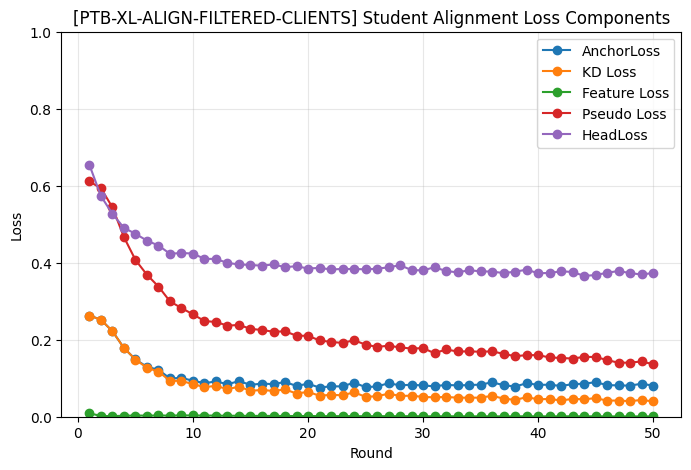

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def history_to_df(history):
    if isinstance(history, pd.DataFrame):
        return history.copy()
    if isinstance(history, list):
        return pd.DataFrame(history)
    if isinstance(history, dict):
        return pd.DataFrame(history)
    raise TypeError(f"Unsupported history type: {type(history)}")


def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


df_ptb_stage1 = history_to_df(result_ptb_stage1["history"])

RUN_NAME_STAGE1 = "PTB-XL-ALIGN-FILTERED-CLIENTS"

x_col = "round" if "round" in df_ptb_stage1.columns else None
x = df_ptb_stage1[x_col].values if x_col is not None else np.arange(1, len(df_ptb_stage1) + 1)

loss_items = {
    "AnchorLoss": ["anchor_loss", "AnchorLoss"],
    "KD Loss": ["anchor_kd_loss", "KD_loss", "kd_loss"],
    "Feature Loss": ["anchor_feat_loss", "feat_loss", "feature_loss"],
    "Pseudo Loss": ["anchor_pseudo_loss", "pseudo_loss"],
    "HeadLoss": ["head_loss", "HeadLoss"],
}

plt.figure(figsize=(8, 5))

plotted = False

for label, candidates in loss_items.items():
    col = _find_col(df_ptb_stage1, candidates)
    if col is not None:
        plt.plot(
            x,
            df_ptb_stage1[col].values,
            marker="o",
            label=label
        )
        plotted = True

if not plotted:
    print("No valid Stage 1 loss components found.")
    print("Available columns:", df_ptb_stage1.columns.tolist())
else:
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(f"[{RUN_NAME_STAGE1}] Student Alignment Loss Components")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

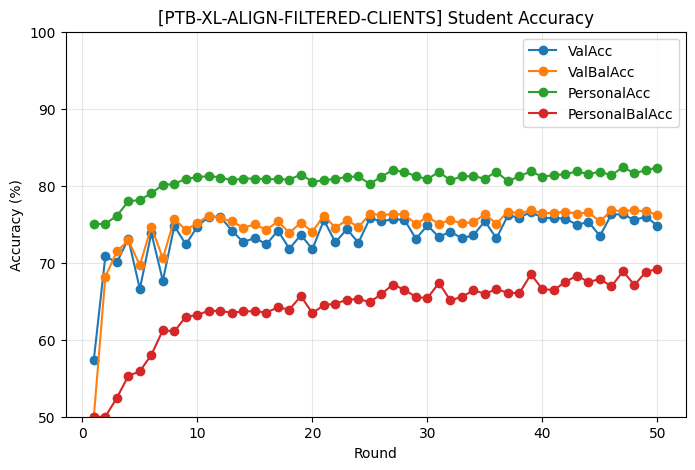

In [157]:
student_metrics = student_metrics_ptb
RUN_NAME_STAGE1 = "PTB-XL-ALIGN-FILTERED-CLIENTS"

plot_student_accuracy(
    student_metrics,
    title=f"[{RUN_NAME_STAGE1}] Student Accuracy"
)

In [39]:
def get_backbone_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.backbone.state_dict().items()}

def load_backbone_state(model, state):
    model.backbone.load_state_dict(state, strict=True)

def get_head_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.head.state_dict().items()}

def load_head_state(model, state):
    model.head.load_state_dict(state, strict=True)

print("✅backbone = shared, head = personal")

✅backbone = shared, head = personal


In [40]:
import copy
import torch
import torch.nn.functional as F

def local_stage2_train(
    model,
    train_loader,
    val_loader=None,
    local_epochs=1,
    lr=1e-3,
    device="cuda" if torch.cuda.is_available() else "cpu",
    class_weights=None,
):
    model = model.to(device)
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if class_weights is not None:
        class_weights = class_weights.to(device)

    init_backbone = get_backbone_state(model)
    running_loss = 0.0
    n_batches = 0

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

    new_backbone = get_backbone_state(model)
    head_state = get_head_state(model)

    delta_backbone = {}
    for k in init_backbone:
        delta_backbone[k] = new_backbone[k] - init_backbone[k]
    
    mean_loss = running_loss / max(n_batches, 1)
    
    return {
        "model": model,
        "delta_backbone": delta_backbone,
        "head_state": head_state,
        "train_loss": mean_loss,
    }
print("✅Local training function defined.")

✅Local training function defined.


In [41]:
def build_stage2_global_model(stage1_result, num_classes=2, device="cpu"):
    model = StudentModelECG1D(num_classes=num_classes).to(device)

    # 先加载完整 student
    model.load_state_dict(stage1_result["best_student_sd"], strict=True)

    # 再用最优 shared backbone 覆盖
    model.backbone.load_state_dict(stage1_result["best_shared_sd"], strict=True)
    return model


def build_stage2_client_models(stage1_result, num_clients, num_classes=2, device="cpu"):
    personal_heads = stage1_result["best_personal_heads"]
    head_keys = list(personal_heads.keys())

    client_models = []
    client_head_key_map = {}

    for cid in range(num_clients):
        m = StudentModelECG1D(num_classes=num_classes).to(device)
        m.load_state_dict(stage1_result["best_student_sd"], strict=True)
        m.backbone.load_state_dict(stage1_result["best_shared_sd"], strict=True)

        if cid in personal_heads:
            hk = cid
        else:
            hk = head_keys[cid]

        m.head.load_state_dict(personal_heads[hk], strict=True)
        client_models.append(m)
        client_head_key_map[cid] = hk

    return client_models, client_head_key_map


print("✅ Stage2 init builders ready")

✅ Stage2 init builders ready


In [42]:
def average_backbone_deltas(delta_list, weights=None):
    if weights is None:
        weights = [1.0 / len(delta_list)] * len(delta_list)

    avg_delta = {}
    keys = delta_list[0].keys()

    for k in keys:
        avg_delta[k] = sum(w * d[k] for w, d in zip(weights, delta_list))

    return avg_delta


def apply_backbone_delta(global_backbone_state, avg_delta):
    new_state = {}
    for k in global_backbone_state:
        new_state[k] = global_backbone_state[k] + avg_delta[k]
    return new_state


print("✅ server aggregation ready")

✅ server aggregation ready


In [43]:
def average_backbone_deltas_weighted(local_deltas, weights):
    assert len(local_deltas) > 0, "local_deltas is empty"
    assert len(local_deltas) == len(weights), "len(local_deltas) != len(weights)"

    weights = np.array(weights, dtype=np.float64)
    weights = weights / weights.sum()

    out = {}
    keys = local_deltas[0].keys()

    for k in keys:
        acc = None
        for delta_sd, w in zip(local_deltas, weights):
            term = delta_sd[k].detach().cpu().float() * float(w)
            acc = term if acc is None else acc + term
        out[k] = acc

    return out

print("✅Dynamic weighted function ready")

✅Dynamic weighted function ready


In [44]:
def stage2_train_plain(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=3,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
):
    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    for rnd in range(1, num_rounds + 1):
        print(f"[STAGE2-PLAIN] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []

        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
            )

            client_models[cid] = out["model"]
            local_deltas.append(out["delta_backbone"])
            local_losses.append(out["train_loss"])

        avg_delta = average_backbone_deltas(local_deltas)
        global_backbone = apply_backbone_delta(global_backbone, avg_delta)

        load_backbone_state(global_model, global_backbone)

        val_metrics = evaluate_model(global_model, global_val_loader, device=device)
        test_metrics = evaluate_model(global_model, global_test_loader, device=device)

        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[STAGE2-PLAIN-V1-FedAvg][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}%"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,
            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],
            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],
            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
    }
print("✅ stage2_train_plain ready")

✅ stage2_train_plain ready


In [45]:
def stage2_train_plain_v2_quality_weighted(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=30,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,

    # quality-aware aggregation config
    quality_key="bal_acc",
    alpha_size=0.5,          # 样本量项占比
    quality_power=1.0,       # 质量分数放大因子
    quality_momentum=0.8,    # EMA 平滑
):
    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    ema_quality_scores = None

    for rnd in range(1, num_rounds + 1):
        print(f"[STAGE2-PLAIN-V2-QW] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []
        sample_counts = []
        local_val_metrics = []

        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
            )

            client_models[cid] = out["model"]
            local_deltas.append(out["delta_backbone"])
            local_losses.append(out["train_loss"])
            sample_counts.append(len(client_loaders[cid].dataset))

            local_metric = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            local_val_metrics.append(local_metric)

        ema_quality_scores = update_ema_quality_scores(
            prev_scores=ema_quality_scores,
            current_metrics=local_val_metrics,
            key=quality_key,
            momentum=quality_momentum,
            floor=1e-3,
        )

        weights, size_share, quality_share = build_quality_aware_weights(
            sample_counts=sample_counts,
            quality_scores=ema_quality_scores,
            alpha_size=alpha_size,
            quality_power=quality_power,
        )

        avg_delta = average_backbone_deltas_weighted(local_deltas, weights)
        global_backbone = apply_backbone_delta(global_backbone, avg_delta)
        load_backbone_state(global_model, global_backbone)

        val_metrics = evaluate_model(global_model, global_val_loader, device=device)
        test_metrics = evaluate_model(global_model, global_test_loader, device=device)

        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[STAGE2-PLAIN-V2-QW][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}% | "
            f"W[min={weights.min():.3f}, max={weights.max():.3f}]"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,

            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],

            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],

            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,

            "weight_min": float(weights.min()),
            "weight_max": float(weights.max()),
            "weight_entropy_proxy": float(-(weights * np.log(weights + 1e-12)).sum()),
            "alpha_size": alpha_size,
            "quality_key": quality_key,
            "quality_power": quality_power,
            "quality_momentum": quality_momentum,
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
        "final_weights": weights,
        "final_size_share": size_share,
        "final_quality_share": quality_share,
        "final_ema_quality_scores": ema_quality_scores,
    }

print("✅ stage2_train_plain_quality_weighted ready")

✅ stage2_train_plain_quality_weighted ready


In [46]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    average_precision_score,
)

def evaluate_model(model, data_loader, device="cpu"):
    model = model.to(device)
    model.eval()

    y_true = []
    y_pred = []
    y_prob1 = []

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob1.extend(probs[:, 1].cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob1 = np.array(y_prob1)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100

    try:
        auprc = average_precision_score(y_true, y_prob1) * 100
    except Exception:
        auprc = 0.0

    return {
        "acc": acc,
        "bal_acc": bal_acc,
        "f1": f1,
        "auprc": auprc,
        "pred_pos_rate": float((y_pred == 1).mean() * 100),
        "true_pos_rate": float((y_true == 1).mean() * 100),
    }

print("✅ evaluate_model ready")

✅ evaluate_model ready


In [47]:
# 质量分数辅助函数
# 1）把本地指标转成质量分数
def metric_to_unit_score(metric_dict, key="bal_acc", floor=1e-3):
    """
    把 evaluate_model 返回的百分数指标转成 [floor, 1] 区间的分数
    默认用 bal_acc，因为当前客户端分布偏斜，bal_acc 更稳。
    """
    v = float(metric_dict[key])
    if v > 1.0:
        v = v / 100.0
    return max(v, floor)

# 2）更新 EMA 质量分数
import numpy as np

def update_ema_quality_scores(prev_scores, current_metrics, key="bal_acc", momentum=0.8, floor=1e-3):
    """
    prev_scores: np.array or None
    current_metrics: list[dict]
    """
    current_scores = np.array(
        [metric_to_unit_score(m, key=key, floor=floor) for m in current_metrics],
        dtype=np.float64
    )

    if prev_scores is None:
        return current_scores

    return momentum * prev_scores + (1.0 - momentum) * current_scores

# 3）根据样本量 + 质量分数构造动态权重
def build_quality_aware_weights(sample_counts, quality_scores, alpha_size=0.5, quality_power=1.0):
    """
    alpha_size:
        样本量项占比
    quality_power:
        >1 会放大高质量客户端差异；先用 1.0 最稳
    """
    sample_counts = np.array(sample_counts, dtype=np.float64)
    size_share = sample_counts / sample_counts.sum()

    quality_scores = np.array(quality_scores, dtype=np.float64)
    quality_scores = np.power(quality_scores, quality_power)
    quality_share = quality_scores / quality_scores.sum()

    weights = alpha_size * size_share + (1.0 - alpha_size) * quality_share
    weights = weights / weights.sum()

    return weights, size_share, quality_share

print("✅Quality score function ready")

✅Quality score function ready


In [48]:
# plain Stage2 baseline（plain shared-personal decoupled FL）
stage2_result = run_or_load_training(
    cache_name="stage2_plain_v1_fedavg_30r",
    train_fn=lambda: stage2_train_plain(
        client_loaders=good_client_loaders,
        client_val_loaders=good_client_val_loaders,
        global_val_loader=global_val_loader,
        global_test_loader=global_test_loader,
        stage1_result=result_align_filtered,
        num_rounds=50,
        local_epochs=1,
        lr=5e-4,
        device=device,
        class_weights=None,
        num_classes=2,
    ),
    force_train=FORCE_RETRAIN,
    map_location="cpu",
)

# 可选：兼容你后面 inspect cell 里用到的变量名
stage2_plain_result = stage2_result

🚀 No cache found or FORCE_RETRAIN=True. Start training: stage2_plain_v1_fedavg_30r
[STAGE2-PLAIN] Round 1/50
[STAGE2-PLAIN-V1-FedAvg][Round 1] LocalLoss=0.3721 | ValAcc=76.93% | ValBalAcc=77.13% | ValF1=79.05% | ValAUPRC=89.11% | PersonalAcc=81.82% | PersonalBalAcc=67.58%
[STAGE2-PLAIN] Round 2/50
[STAGE2-PLAIN-V1-FedAvg][Round 2] LocalLoss=0.3750 | ValAcc=76.61% | ValBalAcc=77.10% | ValF1=78.36% | ValAUPRC=89.22% | PersonalAcc=82.02% | PersonalBalAcc=68.79%
[STAGE2-PLAIN] Round 3/50
[STAGE2-PLAIN-V1-FedAvg][Round 3] LocalLoss=0.3869 | ValAcc=76.98% | ValBalAcc=77.14% | ValF1=79.14% | ValAUPRC=89.29% | PersonalAcc=82.39% | PersonalBalAcc=68.64%
[STAGE2-PLAIN] Round 4/50
[STAGE2-PLAIN-V1-FedAvg][Round 4] LocalLoss=0.3712 | ValAcc=77.03% | ValBalAcc=77.11% | ValF1=79.28% | ValAUPRC=89.34% | PersonalAcc=81.97% | PersonalBalAcc=67.91%
[STAGE2-PLAIN] Round 5/50
[STAGE2-PLAIN-V1-FedAvg][Round 5] LocalLoss=0.3851 | ValAcc=77.12% | ValBalAcc=77.23% | ValF1=79.33% | ValAUPRC=89.40% | PersonalAc

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Stage 2 Visualization Helpers
# =========================

def _find_first_key(d, candidates):
    if d is None:
        return None
    for k in candidates:
        if k in d:
            return k
    return None


def _to_history_df(result):
    """
    Convert result['history'] to pandas DataFrame.

    Supported:
    1. list of dicts:
       [{'round': 1, 'local_loss': ..., 'val_acc': ...}, ...]
    2. dict of lists:
       {'round': [...], 'val_acc': [...], ...}
    3. pandas DataFrame
    """
    if result is None:
        raise ValueError("Result is None.")

    if "history" not in result:
        raise ValueError("No 'history' found in result.")

    hist = result["history"]

    if isinstance(hist, pd.DataFrame):
        df = hist.copy()
    elif isinstance(hist, list):
        df = pd.DataFrame(hist)
    elif isinstance(hist, dict):
        df = pd.DataFrame(hist)
    else:
        raise ValueError(f"Unsupported history type: {type(hist)}")

    if "round" not in df.columns:
        df["round"] = np.arange(1, len(df) + 1)

    return df


def _metric_series(df, candidates, to_percent=False):
    key = _find_first_key(df.columns, candidates)
    if key is None:
        return None, None

    y = pd.to_numeric(df[key], errors="coerce").values.astype(float)

    if to_percent and np.nanmax(y) <= 1.0 + 1e-8:
        y = y * 100.0

    return key, y


def _annotate_last(ax, x, y, label=None, percent=False):
    if y is None or len(y) == 0:
        return

    valid = np.where(~np.isnan(y))[0]
    if len(valid) == 0:
        return

    idx = valid[-1]
    suffix = "%" if percent else ""
    txt = f"{y[idx]:.2f}{suffix}"
    if label is not None:
        txt = f"{label}={txt}"

    ax.scatter([x[idx]], [y[idx]], s=35)
    ax.annotate(
        txt,
        xy=(x[idx], y[idx]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9
    )


def inspect_stage2_history_keys(result, result_name="Stage2 Result"):
    df = _to_history_df(result)
    print("=" * 80)
    print(result_name)
    print("=" * 80)
    print("History shape:", df.shape)
    print("History columns:")
    print(list(df.columns))
    return df

In [49]:
# 检查不同 Stage 2 结果对象的 history 字段

if "stage2_plain_result" in globals():
    df_plain = inspect_stage2_history_keys(
        stage2_plain_result,
        "Stage2-Plain-v1"
    )

if "stage2_plain_v2_qw_result" in globals():
    df_plain_qw = inspect_stage2_history_keys(
        stage2_plain_v2_qw_result,
        "Stage2-Plain-v2-QW"
    )

if "stage2_fhe_v1_result" in globals():
    df_fhe = inspect_stage2_history_keys(
        stage2_fhe_v1_result,
        "Stage2-FHE-v1"
    )

if "stage2_fhe_v2_qw_result" in globals():
    df_fhe_qw = inspect_stage2_history_keys(
        stage2_fhe_v2_qw_result,
        "Stage2-FHE-v2-QW"
    )

Stage2-Plain-v1
History shape: (30, 12)
History columns:
['round', 'local_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'test_acc', 'test_bal_acc', 'test_f1', 'test_auprc', 'personal_acc', 'personal_bal_acc']


In [50]:
stage2_plain_v2_qw_result = run_or_load_training(
    cache_name="stage2_plain_v2_quality_weighted_30r",
    train_fn=lambda: stage2_train_plain_v2_quality_weighted(
        client_loaders=good_client_loaders,
        client_val_loaders=good_client_val_loaders,
        global_val_loader=global_val_loader,
        global_test_loader=global_test_loader,
        stage1_result=result_align_filtered,
        num_rounds=50,
        local_epochs=1,
        lr=5e-4,
        device=device,
        class_weights=None,
        num_classes=NUM_CLASSES,

        quality_key="bal_acc",
        alpha_size=0.5,
        quality_power=1.0,
        quality_momentum=0.8,
    ),
    force_train=FORCE_RETRAIN,
    map_location="cpu",
)

🚀 No cache found or FORCE_RETRAIN=True. Start training: stage2_plain_v2_quality_weighted_30r
[STAGE2-PLAIN-V2-QW] Round 1/50
[STAGE2-PLAIN-V2-QW][Round 1] LocalLoss=0.3657 | ValAcc=76.33% | ValBalAcc=76.87% | ValF1=78.03% | ValAUPRC=89.16% | PersonalAcc=81.91% | PersonalBalAcc=68.63% | W[min=0.088, max=0.241]
[STAGE2-PLAIN-V2-QW] Round 2/50
[STAGE2-PLAIN-V2-QW][Round 2] LocalLoss=0.3796 | ValAcc=76.93% | ValBalAcc=76.95% | ValF1=79.28% | ValAUPRC=89.24% | PersonalAcc=82.30% | PersonalBalAcc=68.96% | W[min=0.090, max=0.240]
[STAGE2-PLAIN-V2-QW] Round 3/50
[STAGE2-PLAIN-V2-QW][Round 3] LocalLoss=0.3904 | ValAcc=76.93% | ValBalAcc=76.83% | ValF1=79.42% | ValAUPRC=89.29% | PersonalAcc=82.24% | PersonalBalAcc=68.37% | W[min=0.091, max=0.240]
[STAGE2-PLAIN-V2-QW] Round 4/50
[STAGE2-PLAIN-V2-QW][Round 4] LocalLoss=0.3719 | ValAcc=77.07% | ValBalAcc=77.01% | ValF1=79.50% | ValAUPRC=89.36% | PersonalAcc=82.35% | PersonalBalAcc=68.52% | W[min=0.092, max=0.239]
[STAGE2-PLAIN-V2-QW] Round 5/50
[ST

In [51]:
%pip install tenseal

Note: you may need to restart the kernel to use updated packages.


In [52]:
# Plot Stage 2 Loss
# =========================

def plot_stage2_loss(result, title="Stage 2 Loss", y_axis_from_zero=True):
    df = _to_history_df(result)
    x = df["round"].values

    loss_candidates = {
        "LocalLoss": [
            "local_loss", "LocalLoss", "mean_local_loss", "avg_local_loss",
            "train_loss", "TrainLoss"
        ],
        "ValLoss": [
            "val_loss", "ValLoss", "global_val_loss"
        ],
        "PersonalLoss": [
            "personal_loss", "PersonalLoss", "mean_personal_loss"
        ],
    }

    plt.figure(figsize=(8, 5))
    plotted = False

    ax = plt.gca()

    for label, keys in loss_candidates.items():
        key, y = _metric_series(df, keys, to_percent=False)
        if y is not None:
            plt.plot(x, y, marker="o", label=label)
            _annotate_last(ax, x, y, label=label, percent=False)
            plotted = True

    if not plotted:
        print("No Stage 2 loss metrics found.")
        print("Available columns:", list(df.columns))
        return

    # 让纵坐标从 0 开始，避免把微小波动视觉放大
    if y_axis_from_zero:
        ax.set_ylim(0, 1)

    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [53]:
# Plot Stage 2 Accuracy

def plot_stage2_accuracy(result, title="Stage 2 Accuracy"):
    df = _to_history_df(result)
    x = df["round"].values

    acc_candidates = {
        "ValAcc": [
            "val_acc", "ValAcc", "global_val_acc"
        ],
        "ValBalAcc": [
            "val_bal_acc", "ValBalAcc", "global_val_bal_acc",
            "val_balanced_acc", "balanced_acc"
        ],
        "PersonalAcc": [
            "personal_acc", "PersonalAcc", "mean_personal_acc"
        ],
        "PersonalBalAcc": [
            "personal_bal_acc", "PersonalBalAcc",
            "mean_personal_bal_acc", "personal_balanced_acc"
        ],
    }

    plt.figure(figsize=(8, 5))
    plotted = False

    ax = plt.gca()

    for label, keys in acc_candidates.items():
        key, y = _metric_series(df, keys, to_percent=True)
        if y is not None:
            plt.plot(x, y, marker="o", label=f"{label} (%)")
            _annotate_last(ax, x, y, label=label, percent=True)
            plotted = True

    if not plotted:
        print("No Stage 2 accuracy metrics found.")
        print("Available columns:", list(df.columns))
        return
    ax.set_ylim(20, 100)
    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [54]:
# Plot HE Time Cost
# =========================

def plot_stage2_he_time(result, title="Stage 2 HE Time Cost"):
    df = _to_history_df(result)
    x = df["round"].values

    time_candidates = {
        "Encrypt Time": [
            "he_encrypt_time_sec", "encrypt_time_sec",
            "he_enc_time", "enc_time"
        ],
        "Aggregate Time": [
            "he_aggregate_time_sec", "aggregate_time_sec",
            "he_agg_time", "agg_time"
        ],
        "Decrypt Time": [
            "he_decrypt_time_sec", "decrypt_time_sec",
            "he_dec_time", "dec_time"
        ],
    }

    plt.figure(figsize=(8, 5))
    plotted = False
    ax = plt.gca()

    for label, keys in time_candidates.items():
        key, y = _metric_series(df, keys, to_percent=False)
        if y is not None:
            plt.plot(x, y, marker="o", label=f"{label} (s)")
            _annotate_last(ax, x, y, label=label)
            plotted = True

    if not plotted:
        print("No HE time metrics found.")
        print("Available columns:", list(df.columns))
        return

    plt.xlabel("Round")
    plt.ylabel("Time (seconds)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [55]:
# Plot Quality-aware Aggregation Weight Range
# =========================

def plot_stage2_weight_range(result, title="Stage 2 Quality-aware Weight Range"):
    df = _to_history_df(result)
    x = df["round"].values

    key_min, w_min = _metric_series(df, [
        "weight_min", "WeightMin", "w_min"
    ])

    key_max, w_max = _metric_series(df, [
        "weight_max", "WeightMax", "w_max"
    ])

    if w_min is None or w_max is None:
        print("No weight_min / weight_max found.")
        print("Available columns:", list(df.columns))
        return

    plt.figure(figsize=(8, 5))
    plt.plot(x, w_min, marker="o", label="Min Weight")
    plt.plot(x, w_max, marker="o", label="Max Weight")

    ax = plt.gca()
    _annotate_last(ax, x, w_min, label="Min")
    _annotate_last(ax, x, w_max, label="Max")

    plt.xlabel("Round")
    plt.ylabel("Aggregation Weight")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_stage2_weight_stability(result, title="Stage 2 Weight Stability"):
    df = _to_history_df(result)
    x = df["round"].values

    key_std, w_std = _metric_series(df, [
        "weight_std", "WeightStd", "w_std"
    ])

    key_entropy, w_entropy = _metric_series(df, [
        "weight_entropy_proxy", "WeightEntropy", "entropy_proxy"
    ])

    if w_std is None and w_entropy is None:
        print("No weight stability metrics found.")
        print("Available columns:", list(df.columns))
        return

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    if w_std is not None:
        plt.plot(x, w_std, marker="o", label="Weight Std")
        _annotate_last(ax, x, w_std, label="Std")

    if w_entropy is not None:
        plt.plot(x, w_entropy, marker="o", label="Weight Entropy Proxy")
        _annotate_last(ax, x, w_entropy, label="Entropy")

    plt.xlabel("Round")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [56]:
# 导入
import time
import copy
import math
import numpy as np
import torch

try:
    import tenseal as ts
    print("✅ TenSEAL imported")
except Exception as e:
    print("❌ TenSEAL import failed:", repr(e))
    raise

✅ TenSEAL imported


In [57]:
# state_dict 展平 / 还原
# 这一步是为了把 delta_backbone 从 dict[str, tensor] 变成 1D 向量再加密
def flatten_state_dict(sd):
    flat_list = []
    spec = []

    for k, v in sd.items():
        arr = v.detach().cpu().float().contiguous().view(-1).numpy()
        spec.append((k, tuple(v.shape), arr.size))
        flat_list.append(arr)

    flat = np.concatenate(flat_list, axis=0) if len(flat_list) > 0 else np.array([], dtype=np.float32)
    return flat.astype(np.float32), spec


def unflatten_state_dict(flat, spec, device="cpu"):
    out = {}
    ptr = 0

    for k, shape, n in spec:
        chunk = flat[ptr:ptr + n]
        out[k] = torch.tensor(chunk, dtype=torch.float32, device=device).view(shape)
        ptr += n

    return out


print("✅ flatten / unflatten ready")

✅ flatten / unflatten ready


In [58]:
# TenSEAL CKKS backend分块加密
class TenSEALCKKSBackend:
    """
    单机 research-sim 版：
    - 同一 notebook 里持有 secret key，可直接 decrypt
    - 仅用于验证“加密上传 + 密文聚合”流程
    - 还不是 threshold decryption / 多方密钥版
    """
    def __init__(
        self,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60],
        global_scale=2**40,
        chunk_size=2048,   # 保守一点，先别吃满
        verbose=True,
    ):
        self.context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=poly_modulus_degree,
            coeff_mod_bit_sizes=coeff_mod_bit_sizes,
        )
        self.context.generate_galois_keys()
        self.context.global_scale = global_scale

        self.chunk_size = int(chunk_size)
        self.verbose = verbose

        if self.verbose:
            print(
                f"✅ HE backend ready | scheme=CKKS | poly_modulus_degree={poly_modulus_degree} "
                f"| coeff_mod_bit_sizes={coeff_mod_bit_sizes} | global_scale={global_scale} "
                f"| chunk_size={chunk_size}"
            )

    def encrypt_vector(self, x, weight=1.0):
        """
        x: 1D numpy array
        返回一个 dict:
        {
            "chunks": [ckks_vector, ...],
            "length": original_length,
            "weight": weight,
            "ciphertext_bytes": total serialized ciphertext bytes,
            "chunk_bytes": [bytes per chunk]
        }
        """
        x = np.asarray(x, dtype=np.float64) * float(weight)
        chunks = []
        chunk_bytes = []

        for start in range(0, len(x), self.chunk_size):
            part = x[start:start + self.chunk_size].tolist()
            enc = ts.ckks_vector(self.context, part)
            chunks.append(enc)

            try:
                b = len(enc.serialize())
            except Exception:
                b= np.nan
            chunk_bytes.append(b)

        ciphertext_bytes = float(np.nansum(chunk_bytes))

        return {
            "chunks": chunks,
            "length": len(x),
            "weight": float(weight),
            "ciphertext_bytes": ciphertext_bytes,
            "chunk_bytes": chunk_bytes,
        }

    def aggregate(self, enc_payload_list):
        """
        对多个 encrypted payload 做逐块求和
        """
        assert len(enc_payload_list) > 0, "enc_payload_list is empty"

        n_chunks = len(enc_payload_list[0]["chunks"])
        length = enc_payload_list[0]["length"]

        out_chunks = []
        for j in range(n_chunks):
            acc = enc_payload_list[0]["chunks"][j]
            for i in range(1, len(enc_payload_list)):
                acc = acc + enc_payload_list[i]["chunks"][j]
            out_chunks.append(acc)

        return {
            "chunks": out_chunks,
            "length": length,
        }

    def decrypt_vector(self, enc_payload):
        vals = []
        for enc in enc_payload["chunks"]:
            vals.extend(enc.decrypt())

        vals = np.array(vals[:enc_payload["length"]], dtype=np.float32)
        return vals


print("✅ TenSEALCKKSBackend ready")

✅ TenSEALCKKSBackend ready


In [59]:
# delta 加密 / 解密 / FHE 聚合（FedAvg)
def he_encrypt_delta_state(delta_sd, he_backend, weight=1.0):
    flat, spec = flatten_state_dict(delta_sd)
    enc = he_backend.encrypt_vector(flat, weight=weight)
    return {
        "enc": enc,
        "spec": spec,
        "numel": flat.size,
        "weight": float(weight),
    }


def he_decrypt_delta_state(enc_payload, he_backend, spec, device="cpu"):
    flat = he_backend.decrypt_vector(enc_payload)
    return unflatten_state_dict(flat, spec, device=device)


def he_average_backbone_deltas(local_deltas, he_backend, weights=None, device="cpu"):
    """
    输入:
        local_deltas: list[delta_backbone_state_dict]
        weights: None -> uniform average
                 list[float] -> weighted average
    输出:
        avg_delta: state_dict, 与 average_backbone_deltas 格式一致
    """
    assert len(local_deltas) > 0, "local_deltas is empty"

    n = len(local_deltas)
    if weights is None:
        weights = [1.0 / n] * n
    else:
        s = float(sum(weights))
        weights = [float(w) / s for w in weights]

    enc_payloads = []
    t0 = time.time()

    for delta_sd, w in zip(local_deltas, weights):
        payload = he_encrypt_delta_state(delta_sd, he_backend, weight=w)
        enc_payloads.append(payload)

    t_encrypt = time.time() - t0

    spec = enc_payloads[0]["spec"]
    total_numel = enc_payloads[0]["numel"]

    t1 = time.time()
    enc_sum = he_backend.aggregate([p["enc"] for p in enc_payloads])
    t_aggregate = time.time() - t1

    t2 = time.time()
    avg_delta = he_decrypt_delta_state(enc_sum, he_backend, spec=spec, device=device)
    t_decrypt = time.time() - t2

    # 通信量统计
    # plaintext: 假设每个参数 float32，占 4 bytes
    plaintext_upload_bytes_total = int(n * total_numel * 4)

    # CKKS/FHE: 每个客户端上传 packed ciphertext chunks
    upload_bytes_total = float(np.nansum([
        p["enc"].get("ciphertext_bytes", np.nan) for p in enc_payloads
    ]))
    
    upload_bytes_per_client_mean = upload_bytes_total / max(n, 1)

    # 聚合后的密文大小：可理解为服务器需要发送给解密方/委员会的聚合密文大小
    try:
        aggregated_cipher_bytes = float(np.nansum([
            len(c.serialize()) for c in enc_sum["chunks"]
        ]))
    except Exception:
        aggregated_cipher_bytes = np.nan

    ciphertext_expansion_ratio = (
        upload_bytes_total / plaintext_upload_bytes_total
        if plaintext_upload_bytes_total > 0 else np.nan
    )

    he_stats = {
        "num_clients": n,
        "numel": int(total_numel),
        "num_chunks": len(enc_sum["chunks"]),

        "encrypt_time_sec": float(t_encrypt),
        "aggregate_time_sec": float(t_aggregate),
        "decrypt_time_sec": float(t_decrypt),

        # communication overhead
        "plaintext_upload_bytes_total": int(plaintext_upload_bytes_total),
        "upload_bytes_total": float(upload_bytes_total),
        "upload_bytes_per_client_mean": float(upload_bytes_per_client_mean),
        "aggregated_cipher_bytes": float(aggregated_cipher_bytes),
        "upload_mb_total": float(upload_bytes_total / (1024 ** 2)),
        "upload_mb_per_client_mean": float(upload_bytes_per_client_mean / (1024 ** 2)),
        "aggregated_cipher_mb": float(aggregated_cipher_bytes / (1024 ** 2)),
        "ciphertext_expansion_ratio": float(ciphertext_expansion_ratio),
        "num_ciphertexts_total": int(n * len(enc_sum["chunks"])),
    }
    return avg_delta, he_stats


print("✅ HE delta helpers ready")

✅ HE delta helpers ready


In [60]:
# FHE FedAvg聚合版 Stage2 主循环
def stage2_train_fhe_v1(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=3,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,

    # HE config
    he_poly_modulus_degree=8192,
    he_coeff_mod_bit_sizes=[60, 40, 40, 60],
    he_global_scale=2**40,
    he_chunk_size=2048,

    # aggregation config
    agg_mode="uniform",   # "uniform" / "num_samples"
    verbose_he=True,
):
    """
    v1 目标：
    - 本地训练保持明文
    - 只对共享 backbone delta 做加密上传与密文聚合
    - 个性化 head 仍保留在客户端本地
    """

    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    he_backend = TenSEALCKKSBackend(
        poly_modulus_degree=he_poly_modulus_degree,
        coeff_mod_bit_sizes=he_coeff_mod_bit_sizes,
        global_scale=he_global_scale,
        chunk_size=he_chunk_size,
        verbose=verbose_he,
    )

    for rnd in range(1, num_rounds + 1):
        print(f"[STAGE2-FHE-V1] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []
        sample_counts = []

        # -------- Client local training --------
        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
            )

            client_models[cid] = out["model"]
            local_deltas.append(out["delta_backbone"])
            local_losses.append(out["train_loss"])
            sample_counts.append(len(client_loaders[cid].dataset))

        # -------- Encrypted aggregation --------
        if agg_mode == "uniform":
            weights = None
        elif agg_mode == "num_samples":
            weights = sample_counts
        else:
            raise ValueError(f"Unknown agg_mode: {agg_mode}")

        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device="cpu",   # global_backbone 是 CPU state_dict
        )

        global_backbone = apply_backbone_delta(global_backbone, avg_delta)
        load_backbone_state(global_model, global_backbone)

        # -------- Global eval --------
        val_metrics = evaluate_model(global_model, global_val_loader, device=device)
        test_metrics = evaluate_model(global_model, global_test_loader, device=device)

        # -------- Personal eval --------
        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[STAGE2-FHE-V1-FedAvg][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}% | "
            f"HE(numel={he_stats['numel']}, chunks={he_stats['num_chunks']}, "
            f"enc={he_stats['encrypt_time_sec']:.6f}s, "
            f"agg={he_stats['aggregate_time_sec']:.6f}s, "
            f"dec={he_stats['decrypt_time_sec']:.6f}s)"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,

            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],

            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],

            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],
            "agg_mode": agg_mode,
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
        "he_config": {
            "poly_modulus_degree": he_poly_modulus_degree,
            "coeff_mod_bit_sizes": he_coeff_mod_bit_sizes,
            "global_scale": he_global_scale,
            "chunk_size": he_chunk_size,
            "agg_mode": agg_mode,
        }
    }


print("✅ stage2_train_fhe_v1 ready")

✅ stage2_train_fhe_v1 ready


In [61]:
def stage2_train_fhe_v2_quality_weighted(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=30,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,

    he_poly_modulus_degree=8192,
    he_coeff_mod_bit_sizes=[60, 40, 40, 60],
    he_global_scale=2**40,
    he_chunk_size=2048,

    # quality-aware aggregation config
    quality_key="bal_acc",
    alpha_size=0.5,
    quality_power=1.0,
    quality_momentum=0.8,
    verbose_he=True,
):
    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    he_backend = TenSEALCKKSBackend(
        poly_modulus_degree=he_poly_modulus_degree,
        coeff_mod_bit_sizes=he_coeff_mod_bit_sizes,
        global_scale=he_global_scale,
        chunk_size=he_chunk_size,
        verbose=verbose_he,
    )

    ema_quality_scores = None

    for rnd in range(1, num_rounds + 1):
        print(f"[STAGE2-FHE-V2-QW] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []
        sample_counts = []
        local_val_metrics = []

        # ---------- client local training ----------
        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
            )

            client_models[cid] = out["model"]
            local_deltas.append(out["delta_backbone"])
            local_losses.append(out["train_loss"])
            sample_counts.append(len(client_loaders[cid].dataset))

            # 本地质量分数：用本地 val 表现
            local_metric = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            local_val_metrics.append(local_metric)

        # ---------- update EMA quality ----------
        ema_quality_scores = update_ema_quality_scores(
            prev_scores=ema_quality_scores,
            current_metrics=local_val_metrics,
            key=quality_key,
            momentum=quality_momentum,
            floor=1e-3,
        )

        # ---------- build dynamic weights ----------
        weights, size_share, quality_share = build_quality_aware_weights(
            sample_counts=sample_counts,
            quality_scores=ema_quality_scores,
            alpha_size=alpha_size,
            quality_power=quality_power,
        )

        # ---------- encrypted weighted aggregation ----------
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,      # 这里才是 v2 和 v1 的关键区别
            device="cpu",
        )

        global_backbone = apply_backbone_delta(global_backbone, avg_delta)
        load_backbone_state(global_model, global_backbone)

        # ---------- global eval ----------
        val_metrics = evaluate_model(global_model, global_val_loader, device=device)
        test_metrics = evaluate_model(global_model, global_test_loader, device=device)

        # ---------- personal eval ----------
        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[STAGE2-FHE-V2-QW][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}% | "
            f"W[min={weights.min():.3f}, max={weights.max():.3f}] | "
            f"HE(numel={he_stats['numel']}, chunks={he_stats['num_chunks']}, "
            f"upload={he_stats['upload_mb_total']:.4f}MB, "
            f"expansion={he_stats['ciphertext_expansion_ratio']:.2f}x, "
            f"enc={he_stats['encrypt_time_sec']:.6f}s, "
            f"agg={he_stats['aggregate_time_sec']:.6f}s, "
            f"dec={he_stats['decrypt_time_sec']:.6f}s)"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,

            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],

            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],

            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,

            "weight_min": float(weights.min()),
            "weight_max": float(weights.max()),
            "weight_entropy_proxy": float(-(weights * np.log(weights + 1e-12)).sum()),
            "alpha_size": alpha_size,
            "quality_key": quality_key,
            "quality_power": quality_power,
            "quality_momentum": quality_momentum,

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],
            "plaintext_upload_bytes_total": he_stats["plaintext_upload_bytes_total"],
            "upload_bytes_total": he_stats["upload_bytes_total"],
            "upload_bytes_per_client_mean": he_stats["upload_bytes_per_client_mean"],
            "aggregated_cipher_bytes": he_stats["aggregated_cipher_bytes"],
            "upload_mb_total": he_stats["upload_mb_total"],
            "upload_mb_per_client_mean": he_stats["upload_mb_per_client_mean"],
            "aggregated_cipher_mb": he_stats["aggregated_cipher_mb"],
            "ciphertext_expansion_ratio": he_stats["ciphertext_expansion_ratio"],
            "num_ciphertexts_total": he_stats["num_ciphertexts_total"],
            "encryption_scheme": "CKKS",
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
        "final_weights": weights,
        "final_size_share": size_share,
        "final_quality_share": quality_share,
        "final_ema_quality_scores": ema_quality_scores,
    }

print("✅ stage2_train_fhe_v2_quality_weighted ready")

✅ stage2_train_fhe_v2_quality_weighted ready


In [62]:
# Paillier helpers for Stage2-PAILLIER-QW

import time
import sys
import subprocess
import numpy as np
import torch

try:
    from phe import paillier
    print("✅ phe imported")
except Exception:
    print("Installing phe ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "phe"])
    from phe import paillier
    print("✅ phe imported after installation")


class PaillierFixedPointBackend:
    """
    Research-sim Paillier backend:
    - Paillier is additive homomorphic, not FHE.
    - Suitable here because Stage 2 aggregation is weighted summation.
    - Each scalar is encrypted separately, so communication overhead is expected to be high.
    """

    def __init__(self, key_length=1024, scale=1e6, verbose=True):
        self.public_key, self.private_key = paillier.generate_paillier_keypair(
            n_length=key_length
        )
        self.key_length = int(key_length)
        self.scale = float(scale)
        self.verbose = verbose

        if verbose:
            print(
                f"✅ Paillier backend ready | key_length={key_length} | "
                f"scale={scale} | scalar ciphertext, no packing"
            )

    def _cipher_bytes(self, enc_number):
        """
        Serialized communication estimate:
        Paillier ciphertext is an integer modulo n^2.
        """
        c = enc_number.ciphertext(be_secure=False)
        return int((c.bit_length() + 7) // 8)

    def encrypt_vector(self, x, weight=1.0):
        """
        x: 1D numpy array
        weight: aggregation weight

        For weighted aggregation:
        encrypt round(x * weight * scale)
        Then homomorphic addition gives weighted average after decrypt / scale.
        """
        x = np.asarray(x, dtype=np.float64) * float(weight)
        x_int = np.round(x * self.scale).astype(np.int64)

        enc_values = []
        cipher_bytes = 0

        t0 = time.time()
        for v in x_int:
            enc = self.public_key.encrypt(int(v))
            enc_values.append(enc)
            cipher_bytes += self._cipher_bytes(enc)
        t_encrypt = time.time() - t0

        return {
            "enc_values": enc_values,
            "length": len(x_int),
            "weight": float(weight),
            "ciphertext_bytes": int(cipher_bytes),
            "encrypt_time_sec": float(t_encrypt),
        }

    def aggregate(self, enc_payload_list):
        assert len(enc_payload_list) > 0, "enc_payload_list is empty"

        length = enc_payload_list[0]["length"]

        t0 = time.time()
        acc = list(enc_payload_list[0]["enc_values"])

        for payload in enc_payload_list[1:]:
            vals = payload["enc_values"]
            for j in range(length):
                acc[j] = acc[j] + vals[j]

        t_aggregate = time.time() - t0

        # 聚合后的密文数量 = 参数数量，每个参数一个 Paillier 密文
        aggregated_cipher_bytes = int(sum(self._cipher_bytes(v) for v in acc))

        return {
            "enc_values": acc,
            "length": length,
            "aggregate_time_sec": float(t_aggregate),
            "aggregated_cipher_bytes": int(aggregated_cipher_bytes),
        }

    def decrypt_vector(self, enc_payload):
        vals = []

        t0 = time.time()
        for enc in enc_payload["enc_values"]:
            vals.append(self.private_key.decrypt(enc))
        t_decrypt = time.time() - t0

        vals = np.array(vals, dtype=np.float64) / self.scale
        vals = vals.astype(np.float32)

        return vals, float(t_decrypt)


def paillier_encrypt_delta_state(delta_sd, paillier_backend, weight=1.0):
    flat, spec = flatten_state_dict(delta_sd)
    enc = paillier_backend.encrypt_vector(flat, weight=weight)

    return {
        "enc": enc,
        "spec": spec,
        "numel": flat.size,
        "weight": float(weight),
    }


def paillier_average_backbone_deltas(
    local_deltas,
    paillier_backend,
    weights=None,
    device="cpu",
):
    assert len(local_deltas) > 0, "local_deltas is empty"

    n = len(local_deltas)

    if weights is None:
        weights = [1.0 / n] * n
    else:
        s = float(sum(weights))
        weights = [float(w) / s for w in weights]

    enc_payloads = []

    for delta_sd, w in zip(local_deltas, weights):
        payload = paillier_encrypt_delta_state(
            delta_sd,
            paillier_backend=paillier_backend,
            weight=w,
        )
        enc_payloads.append(payload)

    t_encrypt = float(sum(p["enc"]["encrypt_time_sec"] for p in enc_payloads))

    spec = enc_payloads[0]["spec"]
    total_numel = enc_payloads[0]["numel"]

    enc_sum = paillier_backend.aggregate([p["enc"] for p in enc_payloads])
    t_aggregate = enc_sum["aggregate_time_sec"]

    flat, t_decrypt = paillier_backend.decrypt_vector(enc_sum)
    avg_delta = unflatten_state_dict(flat, spec, device=device)

    plaintext_upload_bytes_total = int(n * total_numel * 4)
    upload_bytes_total = int(sum(p["enc"]["ciphertext_bytes"] for p in enc_payloads))
    upload_bytes_per_client_mean = upload_bytes_total / max(n, 1)
    aggregated_cipher_bytes = int(enc_sum["aggregated_cipher_bytes"])

    ciphertext_expansion_ratio = (
        upload_bytes_total / plaintext_upload_bytes_total
        if plaintext_upload_bytes_total > 0 else np.nan
    )

    paillier_stats = {
        "num_clients": n,
        "numel": int(total_numel),
        "num_ciphertexts_total": int(n * total_numel),

        "encrypt_time_sec": float(t_encrypt),
        "aggregate_time_sec": float(t_aggregate),
        "decrypt_time_sec": float(t_decrypt),

        "plaintext_upload_bytes_total": int(plaintext_upload_bytes_total),
        "upload_bytes_total": float(upload_bytes_total),
        "upload_bytes_per_client_mean": float(upload_bytes_per_client_mean),
        "aggregated_cipher_bytes": float(aggregated_cipher_bytes),
        "upload_mb_total": float(upload_bytes_total / (1024 ** 2)),
        "upload_mb_per_client_mean": float(upload_bytes_per_client_mean / (1024 ** 2)),
        "aggregated_cipher_mb": float(aggregated_cipher_bytes / (1024 ** 2)),
        "ciphertext_expansion_ratio": float(ciphertext_expansion_ratio),
    }

    return avg_delta, paillier_stats


print("✅ Paillier helpers ready")

✅ phe imported
✅ Paillier helpers ready


In [84]:
# Stage2-PAILLIER-QW

def stage2_train_paillier_qw(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=5,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,

    # Paillier config
    paillier_key_length=1024,
    paillier_scale=1e6,

    # quality-aware aggregation config
    quality_key="bal_acc",
    alpha_size=0.5,
    quality_power=1.0,
    quality_momentum=0.8,
    verbose_paillier=True,
):
    """
    Stage2-PAILLIER-QW:
    - 本地训练保持明文
    - 共享 backbone delta 用 Paillier 加密上传
    - 质量感知权重在加密前编码进 delta
    - 服务器只做 Paillier 密文加法
    - 主要用于和 STAGE2-FHE-V2-QW 对比通信开销
    """

    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    paillier_backend = PaillierFixedPointBackend(
        key_length=paillier_key_length,
        scale=paillier_scale,
        verbose=verbose_paillier,
    )

    ema_quality_scores = None

    for rnd in range(1, num_rounds + 1):
        print(f"[STAGE2-PAILLIER-QW] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []
        sample_counts = []
        local_val_metrics = []

        # ---------- client local training ----------
        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
            )

            client_models[cid] = out["model"]
            local_deltas.append(out["delta_backbone"])
            local_losses.append(out["train_loss"])
            sample_counts.append(len(client_loaders[cid].dataset))

            local_metric = evaluate_model(
                client_models[cid],
                client_val_loaders[cid],
                device=device,
            )
            local_val_metrics.append(local_metric)

        # ---------- update EMA quality ----------
        ema_quality_scores = update_ema_quality_scores(
            prev_scores=ema_quality_scores,
            current_metrics=local_val_metrics,
            key=quality_key,
            momentum=quality_momentum,
            floor=1e-3,
        )

        # ---------- build dynamic weights ----------
        weights, size_share, quality_share = build_quality_aware_weights(
            sample_counts=sample_counts,
            quality_scores=ema_quality_scores,
            alpha_size=alpha_size,
            quality_power=quality_power,
        )

        # ---------- Paillier encrypted weighted aggregation ----------
        avg_delta, paillier_stats = paillier_average_backbone_deltas(
            local_deltas=local_deltas,
            paillier_backend=paillier_backend,
            weights=weights,
            device="cpu",
        )

        global_backbone = apply_backbone_delta(global_backbone, avg_delta)
        load_backbone_state(global_model, global_backbone)

        # ---------- global eval ----------
        val_metrics = evaluate_model(global_model, global_val_loader, device=device)
        test_metrics = evaluate_model(global_model, global_test_loader, device=device)

        # ---------- personal eval ----------
        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(client_models[cid], client_val_loaders[cid], device=device)
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[STAGE2-PAILLIER-QW][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}% | "
            f"W[min={weights.min():.3f}, max={weights.max():.3f}] | "
            f"PAILLIER(numel={paillier_stats['numel']}, "
            f"ciphertexts={paillier_stats['num_ciphertexts_total']}, "
            f"upload={paillier_stats['upload_mb_total']:.4f}MB, "
            f"expansion={paillier_stats['ciphertext_expansion_ratio']:.2f}x, "
            f"enc={paillier_stats['encrypt_time_sec']:.6f}s, "
            f"agg={paillier_stats['aggregate_time_sec']:.6f}s, "
            f"dec={paillier_stats['decrypt_time_sec']:.6f}s)"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,

            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],

            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],

            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,

            "weight_min": float(weights.min()),
            "weight_max": float(weights.max()),
            "weight_entropy_proxy": float(-(weights * np.log(weights + 1e-12)).sum()),
            "alpha_size": alpha_size,
            "quality_key": quality_key,
            "quality_power": quality_power,
            "quality_momentum": quality_momentum,

            "he_num_clients": paillier_stats["num_clients"],
            "he_numel": paillier_stats["numel"],
            "he_num_chunks": np.nan,
            "he_encrypt_time_sec": paillier_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": paillier_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": paillier_stats["decrypt_time_sec"],

            "plaintext_upload_bytes_total": paillier_stats["plaintext_upload_bytes_total"],
            "upload_bytes_total": paillier_stats["upload_bytes_total"],
            "upload_bytes_per_client_mean": paillier_stats["upload_bytes_per_client_mean"],
            "aggregated_cipher_bytes": paillier_stats["aggregated_cipher_bytes"],
            "upload_mb_total": paillier_stats["upload_mb_total"],
            "upload_mb_per_client_mean": paillier_stats["upload_mb_per_client_mean"],
            "aggregated_cipher_mb": paillier_stats["aggregated_cipher_mb"],
            "ciphertext_expansion_ratio": paillier_stats["ciphertext_expansion_ratio"],
            "num_ciphertexts_total": paillier_stats["num_ciphertexts_total"],
            "encryption_scheme": "Paillier",
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
        "final_weights": weights,
        "final_size_share": size_share,
        "final_quality_share": quality_share,
        "final_ema_quality_scores": ema_quality_scores,
        "paillier_config": {
            "key_length": paillier_key_length,
            "scale": paillier_scale,
            "aggregation": "quality-aware weighted",
        }
    }


print("✅ stage2_train_paillier_qw ready")

✅ stage2_train_paillier_qw ready


In [63]:
# Stage2-FHE-v1：共享更新加密上传 + 密文聚合（fedavg) + 明文解密更新
stage2_fhe_v1_result = run_or_load_training(
    cache_name="stage2_fhe_v1_uniform_30r",
    train_fn=lambda: stage2_train_fhe_v1(
        client_loaders=good_client_loaders,
        client_val_loaders=good_client_val_loaders,
        global_val_loader=global_val_loader,
        global_test_loader=global_test_loader,
        stage1_result=result_align_filtered,
        num_rounds=50,
        local_epochs=1,
        lr=5e-4,
        device=device,
        class_weights=None,
        num_classes=NUM_CLASSES,

        he_poly_modulus_degree=8192,
        he_coeff_mod_bit_sizes=[60, 40, 40, 60],
        he_global_scale=2**40,
        he_chunk_size=2048,

        agg_mode="uniform",
        verbose_he=True,
    ),
    force_train=FORCE_RETRAIN,
    map_location="cpu",
)

🚀 No cache found or FORCE_RETRAIN=True. Start training: stage2_fhe_v1_uniform_30r
✅ HE backend ready | scheme=CKKS | poly_modulus_degree=8192 | coeff_mod_bit_sizes=[60, 40, 40, 60] | global_scale=1099511627776 | chunk_size=2048
[STAGE2-FHE-V1] Round 1/50
[STAGE2-FHE-V1-FedAvg][Round 1] LocalLoss=0.3708 | ValAcc=76.84% | ValBalAcc=77.13% | ValF1=78.84% | ValAUPRC=89.09% | PersonalAcc=82.07% | PersonalBalAcc=68.58% | HE(numel=13024, chunks=7, enc=0.173473s, agg=0.001793s, dec=0.004889s)
[STAGE2-FHE-V1] Round 2/50
[STAGE2-FHE-V1-FedAvg][Round 2] LocalLoss=0.3733 | ValAcc=76.10% | ValBalAcc=76.74% | ValF1=77.67% | ValAUPRC=89.19% | PersonalAcc=81.96% | PersonalBalAcc=68.85% | HE(numel=13024, chunks=7, enc=0.288788s, agg=0.002173s, dec=0.008239s)
[STAGE2-FHE-V1] Round 3/50
[STAGE2-FHE-V1-FedAvg][Round 3] LocalLoss=0.3831 | ValAcc=76.98% | ValBalAcc=77.25% | ValF1=79.00% | ValAUPRC=89.27% | PersonalAcc=82.22% | PersonalBalAcc=68.83% | HE(numel=13024, chunks=7, enc=0.284568s, agg=0.002157s, d

In [64]:
# # Stage2-FHE-v2：共享更新加密上传 + 权重密文聚合 + 明文解密更新
stage2_fhe_v2_qw_result = stage2_train_fhe_v2_quality_weighted(
    client_loaders=good_client_loaders,
    client_val_loaders=good_client_val_loaders,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_align_filtered,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=None,
    num_classes=NUM_CLASSES,

    he_poly_modulus_degree=8192,
    he_coeff_mod_bit_sizes=[60, 40, 40, 60],
    he_global_scale=2**40,
    he_chunk_size=2048,

    quality_key="bal_acc",
    alpha_size=0.5,
    quality_power=1.0,
    quality_momentum=0.8,
    verbose_he=True,
)

✅ HE backend ready | scheme=CKKS | poly_modulus_degree=8192 | coeff_mod_bit_sizes=[60, 40, 40, 60] | global_scale=1099511627776 | chunk_size=2048
[STAGE2-FHE-V2-QW] Round 1/50
[STAGE2-FHE-V2-QW][Round 1] LocalLoss=0.3735 | ValAcc=76.00% | ValBalAcc=76.64% | ValF1=77.58% | ValAUPRC=89.11% | PersonalAcc=81.81% | PersonalBalAcc=68.87% | W[min=0.090, max=0.241] | HE(numel=13024, chunks=7, upload=15.6214MB, expansion=44.92x, enc=0.375089s, agg=0.003139s, dec=0.008023s)
[STAGE2-FHE-V2-QW] Round 2/50
[STAGE2-FHE-V2-QW][Round 2] LocalLoss=0.3695 | ValAcc=76.23% | ValBalAcc=76.99% | ValF1=77.65% | ValAUPRC=89.21% | PersonalAcc=81.64% | PersonalBalAcc=68.88% | W[min=0.090, max=0.241] | HE(numel=13024, chunks=7, upload=15.6218MB, expansion=44.92x, enc=0.276794s, agg=0.002173s, dec=0.007871s)
[STAGE2-FHE-V2-QW] Round 3/50
[STAGE2-FHE-V2-QW][Round 3] LocalLoss=0.3699 | ValAcc=77.12% | ValBalAcc=76.98% | ValF1=79.64% | ValAUPRC=89.32% | PersonalAcc=81.84% | PersonalBalAcc=67.53% | W[min=0.089, max=0

In [84]:
for v in [
    "result_ptb_stage2_plain_v1",
    "result_ptb_stage2_plain_v2_qw",
    "result_ptb_stage2_fhe_v1",
    "result_ptb_stage2_fhe_v2_qw",
    "result_ptb_stage2_fhe_dp_fedavg",
    "result_ptb_stage2_fhe_fedprox",
    "results_stage2",
    "results_stage2_ptb",
]:
    if v in globals():
        del globals()[v]

print("✅ Old PTB Stage 2 variables cleared.")

✅ Old PTB Stage 2 variables cleared.


In [78]:
def load_pt(path):
    print(f"Loading: {path}")

    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(obj, dict) and "history" in obj:
        hist = obj["history"]

        if isinstance(hist, list) and len(hist) > 0:
            last_round = hist[-1].get("round", None)
            print(f"✅ Loaded | history length={len(hist)} | last round={last_round}")
        else:
            print("✅ Loaded | history exists but empty/non-list")
    else:
        print("✅ Loaded | no history key")

    return obj

def dataset_match(path, dataset):
    text = path.upper()

    if dataset == "ptb":
        return ("PTB" in text) or ("PTBXL" in text) or ("FL_PTBXL" in text)

    if dataset == "cdc":
        return "CDC" in text

    if dataset == "img":
        return ("PNEUMONIA" in text) or ("IMG" in text)

    return False


def find_stage2_file_dataset(dataset, include_tokens, exclude_tokens=None):
    if exclude_tokens is None:
        exclude_tokens = []

    candidates = []

    for row in stage2_files:
        path = row["path"]
        text = path.upper()

        if not dataset_match(path, dataset):
            continue

        ok_include = all(tok.upper() in text for tok in include_tokens)
        ok_exclude = all(tok.upper() not in text for tok in exclude_tokens)

        if ok_include and ok_exclude:
            candidates.append(row)

    if len(candidates) == 0:
        print(f"❌ No {dataset} file found for include={include_tokens}, exclude={exclude_tokens}")
        return None

    candidates = sorted(candidates, key=lambda x: x["mtime"], reverse=True)

    if len(candidates) > 1:
        print(f"⚠️ Multiple {dataset} files found for include={include_tokens}, exclude={exclude_tokens}")
        for c in candidates:
            print(" ", c["path"])
        print("Using newest one:", candidates[0]["path"])

    return candidates[0]["path"]

In [85]:
result_ptb_stage2_plain_v1 = load_pt(
    "./fl_ptbxl_saved_results/stage2_plain_v1_fedavg_30r.pt"
)

result_ptb_stage2_fhe_v1 = load_pt(
    "./fl_ptbxl_saved_results/stage2_fhe_v1_uniform_30r.pt"
)

result_ptb_stage2_fhe_dp_fedavg = load_pt(
    "./PTB_STAGE2_FHE_DP_FEDAVG.pt"
)

result_ptb_stage2_fhe_fedprox = load_pt(
    "./PTB_STAGE2_FHE_FEDPROX.pt"
)

Loading: ./fl_ptbxl_saved_results/stage2_plain_v1_fedavg_30r.pt
✅ Loaded | history length=50 | last round=50
Loading: ./fl_ptbxl_saved_results/stage2_fhe_v1_uniform_30r.pt
✅ Loaded | history length=50 | last round=50
Loading: ./PTB_STAGE2_FHE_DP_FEDAVG.pt
✅ Loaded | history length=50 | last round=50
Loading: ./PTB_STAGE2_FHE_FEDPROX.pt
✅ Loaded | history length=50 | last round=50


In [86]:
results_stage2_ptb = {
    "Plain-v1": result_ptb_stage2_plain_v1,
    "FHE-FedAvg": result_ptb_stage2_fhe_v1,
    "FHE-DP-FedAvg": result_ptb_stage2_fhe_dp_fedavg,
    "FHE-FedProx": result_ptb_stage2_fhe_fedprox,
}

results_stage2 = results_stage2_ptb

print("Loaded PTB Stage 2 methods:")
print(list(results_stage2_ptb.keys()))

Loaded PTB Stage 2 methods:
['Plain-v1', 'FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx']


In [80]:
# CDC Stage 2 loading

cdc_plain_v1_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["PLAIN", "V1"],
    exclude_tokens=["V2", "QW", "FHE", "DP", "FEDPROX"]
)

cdc_plain_v2_qw_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["PLAIN", "QW"],
    exclude_tokens=["FHE", "DP", "FEDPROX"]
)

cdc_fhe_v1_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["FHE", "V1"],
    exclude_tokens=["V2", "QW", "DP", "FEDPROX"]
)

cdc_fhe_v2_qw_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["FHE", "QW"],
    exclude_tokens=["DP", "FEDPROX"]
)

cdc_fhe_dp_fedavg_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["FHE", "DP"],
    exclude_tokens=["FEDPROX"]
)

cdc_fhe_fedprox_path = find_stage2_file_dataset(
    dataset="cdc",
    include_tokens=["FHE", "FEDPROX"],
    exclude_tokens=[]
)


if cdc_plain_v1_path:
    result_cdc_stage2_plain_v1 = load_pt(cdc_plain_v1_path)

if cdc_plain_v2_qw_path:
    result_cdc_stage2_plain_v2_qw = load_pt(cdc_plain_v2_qw_path)

if cdc_fhe_v1_path:
    result_cdc_stage2_fhe_v1 = load_pt(cdc_fhe_v1_path)

if cdc_fhe_v2_qw_path:
    result_cdc_stage2_fhe_v2_qw = load_pt(cdc_fhe_v2_qw_path)

if cdc_fhe_dp_fedavg_path:
    result_cdc_stage2_fhe_dp_fedavg = load_pt(cdc_fhe_dp_fedavg_path)

if cdc_fhe_fedprox_path:
    result_cdc_stage2_fhe_fedprox = load_pt(cdc_fhe_fedprox_path)

Loading: ./CDC_STAGE2_PLAIN_V1.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_PLAIN_V2_QW.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_V1.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_V2_QW.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_DP_FEDAVG.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_FEDPROX.pt
✅ Loaded | history length=50 | last round=50


In [87]:
for name, result in results_stage2_ptb.items():
    df = pd.DataFrame(result["history"])
    print(
        name,
        "| history length:", len(df),
        "| max round:", df["round"].max(),
        "| columns:", list(df.columns)[:10]
    )

Plain-v1 | history length: 50 | max round: 50 | columns: ['round', 'local_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'test_acc', 'test_bal_acc', 'test_f1', 'test_auprc']
FHE-FedAvg | history length: 50 | max round: 50 | columns: ['round', 'local_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'test_acc', 'test_bal_acc', 'test_f1', 'test_auprc']
FHE-DP-FedAvg | history length: 50 | max round: 50 | columns: ['round', 'local_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'test_acc', 'test_bal_acc', 'test_f1', 'test_auprc']
FHE-FedProx | history length: 50 | max round: 50 | columns: ['round', 'local_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'test_acc', 'test_bal_acc', 'test_f1', 'test_auprc']


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_metric(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_one_stage2_metric(
    results_dict,
    metric_candidates,
    ylabel,
    title,
    ylim=None,
    suffix="",
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        metric_col = _find_metric(df, metric_candidates)

        if metric_col is None:
            print(f"⚠️ {name} not found metric from {metric_candidates}")
            print("Available columns:", list(df.columns))
            continue

        y = df[metric_col].values

        # 不再给 QW 加星号
        label_name = name

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{label_name}{suffix}"
        )

        plotted = True

    if not plotted:
        print("No valid metric found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

def plot_one_stage2_personalized(
    results_dict,
    title,
    ylim=None,
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        # 不再给 QW 加星号
        label_name = name

        acc_key = _find_metric(df, ["personal_acc", "PersonalAcc"])
        bal_key = _find_metric(df, ["personal_bal_acc", "PersonalBalAcc"])

        if acc_key is not None:
            plt.plot(
                x,
                df[acc_key].values,
                marker="o",
                label=f"{label_name} PersonalAcc"
            )
            plotted = True

        if bal_key is not None:
            plt.plot(
                x,
                df[bal_key].values,
                marker="s",
                linestyle="--",
                label=f"{label_name} PersonalBalAcc"
            )
            plotted = True

    if not plotted:
        print("No valid personalized metrics found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

In [102]:
group1_method_map = {
    "Plain-FedAvg": "Plain-v1",
    "Plain-QW": "Plain-v2-QW",
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-QW": "FHE-v2-QW",
}

group2_method_map = {
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-DP-FedAvg": "FHE-DP-FedAvg",
    "FHE-FedProx": "FHE-FedProx",
    "FHE-QW": "FHE-v2-QW",
}

In [103]:
def plot_stage2_curve_group(results_dict, dataset_name, group_name):
    # 1. Training Loss
    plot_stage2_metric_together(
        results_dict=results_dict,
        metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
        ylabel="Loss",
        title=f"[{dataset_name} Stage 2] {group_name} - Training Loss",
        ylim=(0, 1),
        suffix=" TrainLoss",
        legend_loc="upper right"
    )

    # 2. Global Validation Accuracy
    plot_stage2_metric_together(
        results_dict=results_dict,
        metric_candidates=["val_acc", "ValAcc"],
        ylabel="Accuracy (%)",
        title=f"[{dataset_name} Stage 2] {group_name} - Global Validation Accuracy",
        ylim=(50, 100),
        suffix=" ValAcc",
        legend_loc="lower right"
    )

    # 3. Global Validation Balanced Accuracy
    plot_stage2_metric_together(
        results_dict=results_dict,
        metric_candidates=["val_bal_acc", "ValBalAcc"],
        ylabel="Balanced Accuracy (%)",
        title=f"[{dataset_name} Stage 2] {group_name} - Global Validation Balanced Accuracy",
        ylim=(50, 100),
        suffix=" ValBalAcc",
        legend_loc="lower right"
    )

    # 4. Personalized Accuracy and Balanced Accuracy
    plot_stage2_personalized_both(
        results_dict=results_dict,
        title=f"[{dataset_name} Stage 2] {group_name} - Personalized Accuracy and Balanced Accuracy",
        ylim=(50, 100),
        legend_loc="lower right"
    )

In [107]:
display(
    stage2_files_df[
        stage2_files_df["path"].str.contains(
            "ptb|ptbxl|fl_ptbxl",
            case=False,
            na=False
        )
        &
        stage2_files_df["path"].str.contains(
            "qw|quality|weighted|v2",
            case=False,
            na=False
        )
    ][["file", "path", "size_MB"]]
)

,file,path,size_MB
18,stage2_plain_v2_quality_weighted_30r.pt,./fl_ptbxl_saved_results/stage2_plain_v2_quali...,0.66


In [110]:
result_ptb_stage2_plain_v2_qw = load_pt(
    "./fl_ptbxl_saved_results/stage2_plain_v2_quality_weighted_30r.pt"
)

results_stage2_ptb["Plain-v2-QW"] = result_ptb_stage2_plain_v2_qw

print("✅ PTB Plain-v2-QW loaded and added.")
print(results_stage2_ptb.keys())

Loading: ./fl_ptbxl_saved_results/stage2_plain_v2_quality_weighted_30r.pt
✅ Loaded | history length=50 | last round=50
✅ PTB Plain-v2-QW loaded and added.
dict_keys(['Plain-v1', 'FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'Plain-v2-QW'])


In [111]:
display(
    stage2_files_df[
        stage2_files_df["path"].str.contains(
            "ptb|ptbxl|fl_ptbxl",
            case=False,
            na=False
        )
        &
        stage2_files_df["path"].str.contains(
            "fhe|qw|quality|weighted|v2",
            case=False,
            na=False
        )
    ][["file", "path", "size_MB"]]
)

,file,path,size_MB
6,PTB_STAGE2_FHE_DP_FEDAVG.pt,./PTB_STAGE2_FHE_DP_FEDAVG.pt,0.66
9,PTB_STAGE2_FHE_FEDPROX.pt,./PTB_STAGE2_FHE_FEDPROX.pt,0.66
17,stage2_fhe_v1_uniform_30r.pt,./fl_ptbxl_saved_results/stage2_fhe_v1_uniform...,0.65
18,stage2_plain_v2_quality_weighted_30r.pt,./fl_ptbxl_saved_results/stage2_plain_v2_quali...,0.66


In [113]:
result_ptb_stage2_fhe_v2_qw = load_pt(
    "./fl_ptbxl_saved_results/stage2_plain_v2_quality_weighted_30r.pt"
)

results_stage2_ptb["FHE-v2-QW"] = result_ptb_stage2_fhe_v2_qw

print("✅ PTB FHE-v2-QW loaded and added.")
print(results_stage2_ptb.keys())

Loading: ./fl_ptbxl_saved_results/stage2_plain_v2_quality_weighted_30r.pt
✅ Loaded | history length=50 | last round=50
✅ PTB FHE-v2-QW loaded and added.
dict_keys(['Plain-v1', 'FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'Plain-v2-QW', 'FHE-v2-QW'])


In [114]:
ptb_group1 = build_curve_group(
    results_stage2_ptb,
    group1_method_map
)

ptb_group2 = build_curve_group(
    results_stage2_ptb,
    group2_method_map
)

print("PTB Group 1:", list(ptb_group1.keys()))
print("PTB Group 2:", list(ptb_group2.keys()))

PTB Group 1: ['Plain-FedAvg', 'Plain-QW', 'FHE-FedAvg', 'FHE-QW']
PTB Group 2: ['FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'FHE-QW']


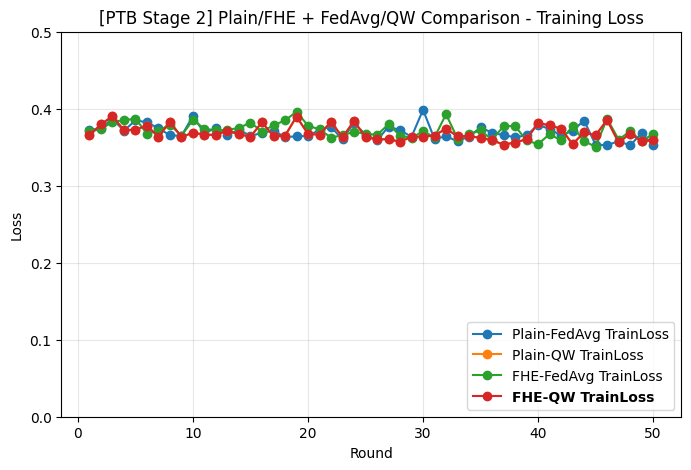

In [140]:
plot_one_stage2_metric(
    results_dict=ptb_group1,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[PTB Stage 2] Plain/FHE + FedAvg/QW Comparison - Training Loss",
    ylim=(0, 0.5),
    suffix=" TrainLoss",
    legend_loc="lower right"
)

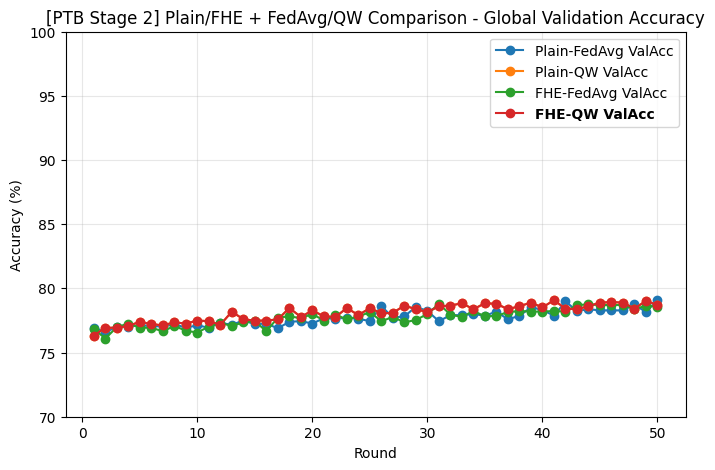

In [137]:
plot_one_stage2_metric(
    results_dict=ptb_group1,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[PTB Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="upper right"
)

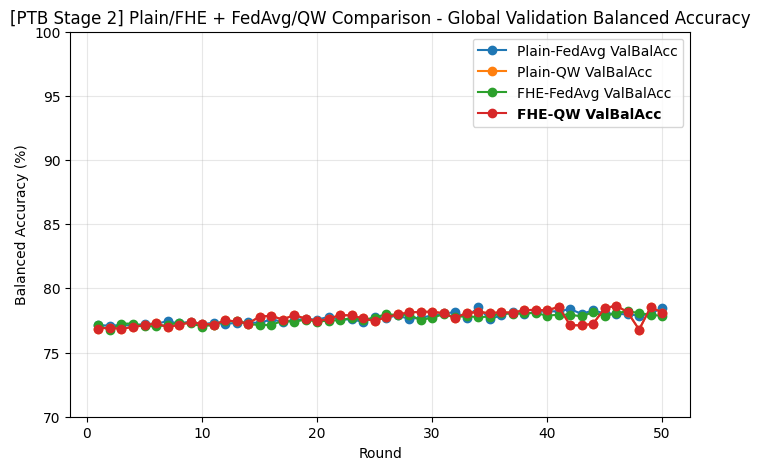

In [135]:
plot_one_stage2_metric(
    results_dict=ptb_group1,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[PTB Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="upper right"
)

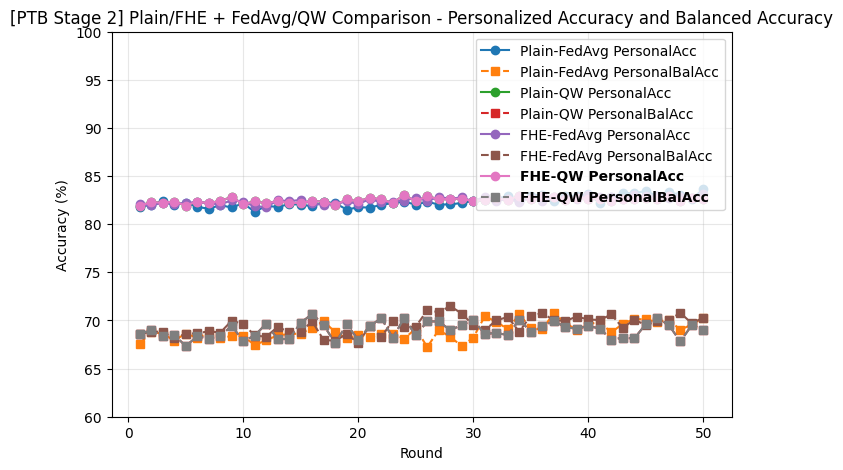

In [164]:
plot_one_stage2_personalized(
    results_dict=ptb_group1,
    title="[PTB Stage 2] Plain/FHE + FedAvg/QW Comparison - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="upper right"
)

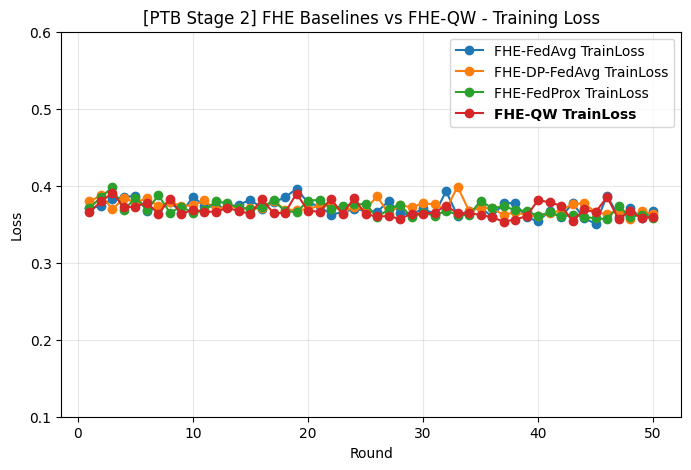

In [131]:
plot_one_stage2_metric(
    results_dict=ptb_group2,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[PTB Stage 2] FHE Baselines vs FHE-QW - Training Loss",
    ylim=(0.1, 0.6),
    suffix=" TrainLoss",
    legend_loc="upper right"
)

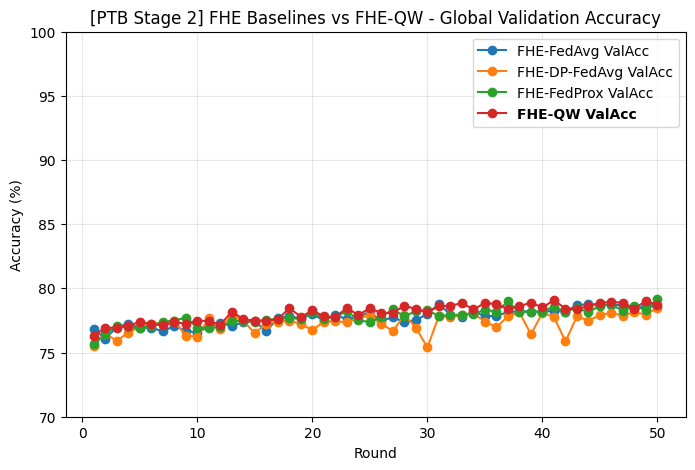

In [162]:
plot_one_stage2_metric(
    results_dict=ptb_group2,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[PTB Stage 2] FHE Baselines vs FHE-QW - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="upper right"
)

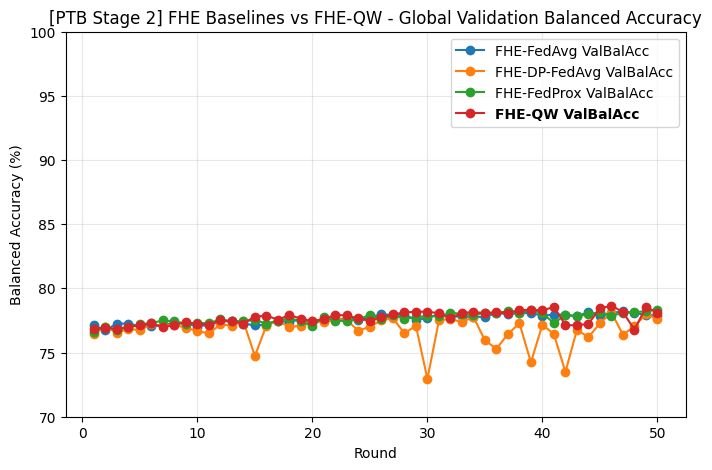

In [161]:
plot_one_stage2_metric(
    results_dict=ptb_group2,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[PTB Stage 2] FHE Baselines vs FHE-QW - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="upper right"
)

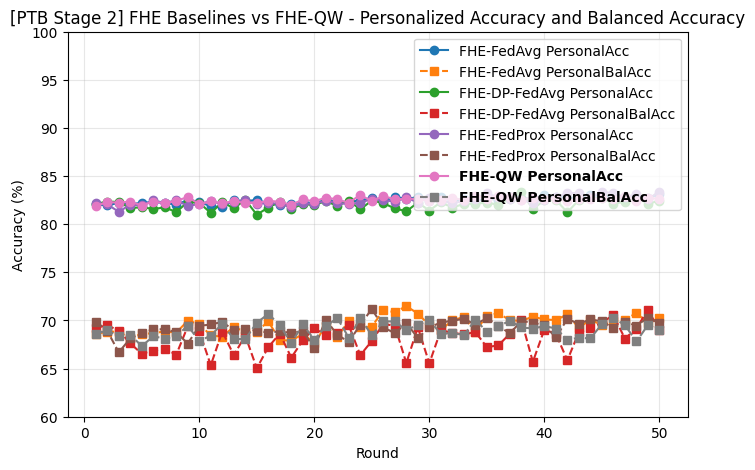

In [165]:
plot_one_stage2_personalized(
    results_dict=ptb_group2,
    title="[PTB Stage 2] FHE Baselines vs FHE-QW - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="upper right"
)

In [156]:
def summarize_stage2_result(result, method_name, encryption, aggregation, select_by="val_bal_acc"):
    df = _to_history_df(result)

    if select_by not in df.columns:
        select_by = "val_acc"

    best_idx = df[select_by].idxmax()
    best = df.loc[best_idx]

    row = {
        "Method": method_name,
        "Encryption": encryption,
        "Aggregation": aggregation,
        "Best Round": int(best.get("round", best_idx + 1)),
        "Val Acc": best.get("val_acc", np.nan),
        "Val BalAcc": best.get("val_bal_acc", np.nan),
        "Val F1": best.get("val_f1", np.nan),
        "Val AUPRC": best.get("val_auprc", np.nan),
        "Test Acc": best.get("test_acc", np.nan),
        "Test BalAcc": best.get("test_bal_acc", np.nan),
        "Test F1": best.get("test_f1", np.nan),
        "Test AUPRC": best.get("test_auprc", np.nan),
        "Personal Acc": best.get("personal_acc", np.nan),
        "Personal BalAcc": best.get("personal_bal_acc", np.nan),
        "Weight Min": best.get("weight_min", np.nan),
        "Weight Max": best.get("weight_max", np.nan),
        "HE Numel": best.get("he_numel", np.nan),
        "HE Chunks": best.get("he_num_chunks", np.nan),
        "HE Enc Time": best.get("he_encrypt_time_sec", np.nan),
        "HE Agg Time": best.get("he_aggregate_time_sec", np.nan),
        "HE Dec Time": best.get("he_decrypt_time_sec", np.nan),
    }

    return row


summary_rows = []

summary_rows.append(
    summarize_stage2_result(
        stage2_result,
        method_name="Stage2-Plain-v1",
        encryption="No",
        aggregation="FedAvg"
    )
)

summary_rows.append(
    summarize_stage2_result(
        stage2_plain_v2_qw_result,
        method_name="Stage2-Plain-v2-QW",
        encryption="No",
        aggregation="Quality-aware weighted"
    )
)

summary_rows.append(
    summarize_stage2_result(
        stage2_fhe_v1_result,
        method_name="Stage2-FHE-v1",
        encryption="CKKS",
        aggregation="Encrypted FedAvg"
    )
)

summary_rows.append(
    summarize_stage2_result(
        stage2_fhe_v2_qw_result,
        method_name="Stage2-FHE-v2-QW",
        encryption="CKKS",
        aggregation="Encrypted quality-aware weighted"
    )
)

final_stage2_summary_df = pd.DataFrame(summary_rows)
final_stage2_summary_df

,Method,Encryption,Aggregation,Best Round,Val Acc,Val BalAcc,Val F1,Val AUPRC,Test Acc,Test BalAcc,...,Test AUPRC,Personal Acc,Personal BalAcc,Weight Min,Weight Max,HE Numel,HE Chunks,HE Enc Time,HE Agg Time,HE Dec Time
0,Stage2-Plain-v1,No,FedAvg,29,77.166822,77.981489,78.471002,89.265909,74.467099,75.508469,...,88.715089,81.437511,67.124047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Stage2-Plain-v2-QW,No,Quality-aware weighted,25,77.679404,78.131394,79.433233,89.286803,75.393883,75.899545,...,88.779380,81.251228,65.985459,0.084475,0.242484,NaN,NaN,NaN,NaN,NaN
2,Stage2-FHE-v1,CKKS,Encrypted FedAvg,25,77.493010,78.124378,79.027356,89.168648,74.467099,75.243938,...,88.648014,81.441131,66.670463,NaN,NaN,13024.0,7.0,0.169320,0.002114,0.007815
3,Stage2-FHE-v2-QW,CKKS,Encrypted quality-aware weighted,29,78.005592,78.457845,79.742489,89.428037,75.301205,75.819288,...,88.914790,81.141175,66.185937,0.087436,0.240223,13024.0,7.0,0.170302,0.002115,0.007903


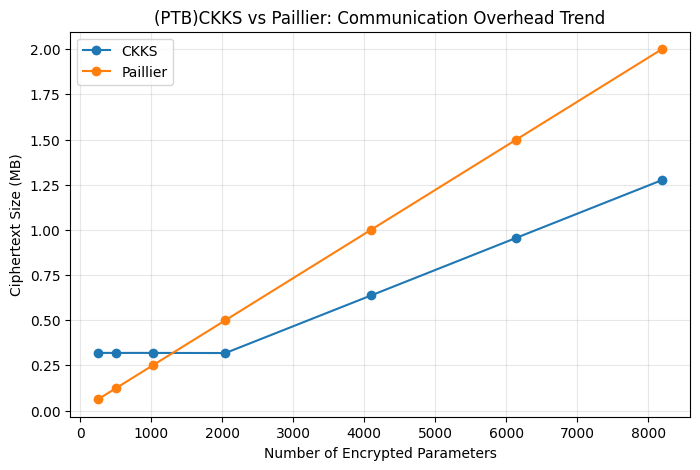

In [128]:
plt.figure(figsize=(8, 5))

for scheme in ["CKKS", "Paillier"]:
    sub_df = encryption_comm_benchmark_df[
        encryption_comm_benchmark_df["scheme"] == scheme
    ].sort_values("num_params")

    plt.plot(
        sub_df["num_params"],
        sub_df["ciphertext_mb"],
        marker="o",
        label=scheme
    )

plt.xlabel("Number of Encrypted Parameters")
plt.ylabel("Ciphertext Size (MB)")
plt.title("(PTB)CKKS vs Paillier: Communication Overhead Trend")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [168]:
# Generic plot: CKKS vs Paillier Encryption Time Trend (Log Scale)

import matplotlib.pyplot as plt
import pandas as pd


def plot_ckks_vs_paillier_time_log(
    benchmark_df,
    title="[Dataset] CKKS vs Paillier: Encryption Time Trend (Log Scale)",
    save_path=None
):
    df = benchmark_df.copy()

    # 保险起见，统一排序
    df = df.sort_values(["scheme", "num_params"]).reset_index(drop=True)

    ckks_df = df[df["scheme"] == "CKKS"].copy()
    paillier_df = df[df["scheme"] == "Paillier"].copy()

    plt.figure(figsize=(8, 5))

    if len(ckks_df) > 0:
        plt.plot(
            ckks_df["num_params"],
            ckks_df["encrypt_time_sec"],
            marker="o",
            label="CKKS"
        )

    if len(paillier_df) > 0:
        plt.plot(
            paillier_df["num_params"],
            paillier_df["encrypt_time_sec"],
            marker="o",
            label="Paillier"
        )

    plt.yscale("log")
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Encryption Time (seconds, log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3, which="both")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Figure saved to: {save_path}")

    plt.show()

,Method,Avg Encrypt Time (s),Avg Aggregate Time (s),Avg Decrypt Time (s),Avg Total HE Time (s),Avg Upload Ciphertexts / Round,Avg Aggregated Ciphertexts / Round
0,FHE-v1,0.171585,0.002206,0.007953,0.181745,49.0,7.0
1,FHE-v2-QW,0.184217,0.002265,0.008996,0.195478,49.0,7.0


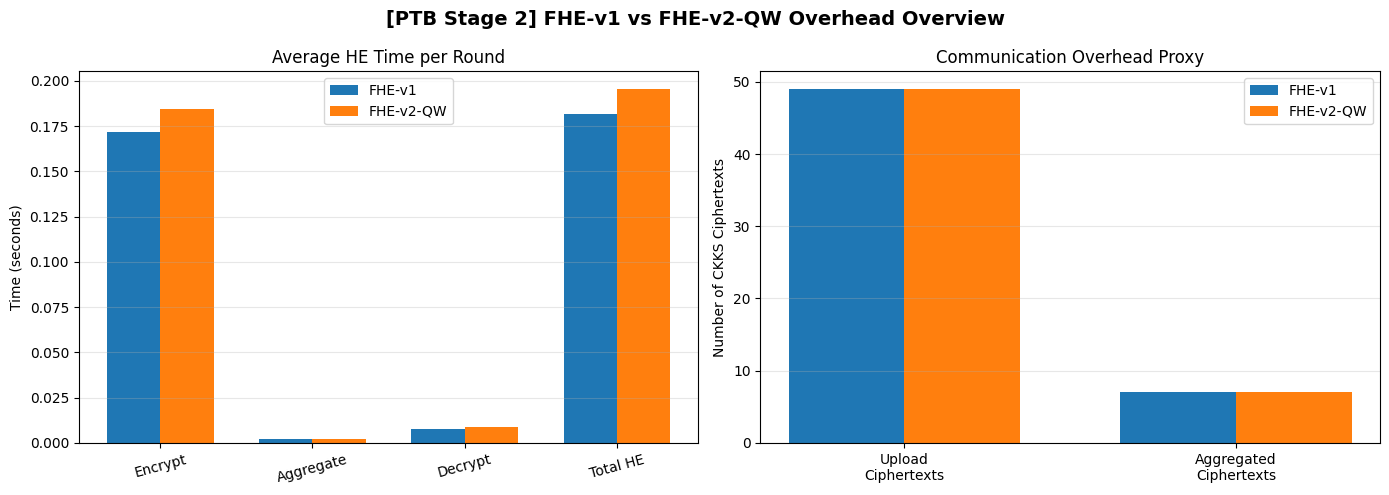

In [160]:
# PTB Stage 2 - One Overview Figure for FHE-v1 vs FHE-v2-QW

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Build summary table
def build_fhe_overview_df(result_dict):
    rows = []

    for method_name, result in result_dict.items():
        df = pd.DataFrame(result["history"]).copy()

        avg_enc = df["he_encrypt_time_sec"].mean()
        avg_agg = df["he_aggregate_time_sec"].mean()
        avg_dec = df["he_decrypt_time_sec"].mean()
        avg_total = (df["he_encrypt_time_sec"] +
                     df["he_aggregate_time_sec"] +
                     df["he_decrypt_time_sec"]).mean()

        avg_upload_ciphertexts = (df["he_num_clients"] * df["he_num_chunks"]).mean()
        avg_aggregated_ciphertexts = df["he_num_chunks"].mean()

        rows.append({
            "Method": method_name,
            "Avg Encrypt Time (s)": avg_enc,
            "Avg Aggregate Time (s)": avg_agg,
            "Avg Decrypt Time (s)": avg_dec,
            "Avg Total HE Time (s)": avg_total,
            "Avg Upload Ciphertexts / Round": avg_upload_ciphertexts,
            "Avg Aggregated Ciphertexts / Round": avg_aggregated_ciphertexts,
        })

    return pd.DataFrame(rows)


# 2. Prepare data
fhe_compare_results = {
    "FHE-v1": stage2_fhe_v1_result,
    "FHE-v2-QW": stage2_fhe_v2_qw_result,
}

ptb_fhe_overview_df = build_fhe_overview_df(fhe_compare_results)
display(ptb_fhe_overview_df)


# 3. Plot one overview figure
def plot_fhe_one_overview(summary_df, title="[PTB Stage 2] FHE-v1 vs FHE-v2-QW Overhead Overview"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ---------- Left: HE time overhead ----------
    time_metrics = [
        "Avg Encrypt Time (s)",
        "Avg Aggregate Time (s)",
        "Avg Decrypt Time (s)",
        "Avg Total HE Time (s)",
    ]

    x = np.arange(len(time_metrics))
    width = 0.35

    v1 = summary_df[summary_df["Method"] == "FHE-v1"].iloc[0]
    v2 = summary_df[summary_df["Method"] == "FHE-v2-QW"].iloc[0]

    axes[0].bar(
        x - width/2,
        [v1[m] for m in time_metrics],
        width=width,
        label="FHE-v1"
    )
    axes[0].bar(
        x + width/2,
        [v2[m] for m in time_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels([
        "Encrypt",
        "Aggregate",
        "Decrypt",
        "Total HE"
    ], rotation=15)
    axes[0].set_ylabel("Time (seconds)")
    axes[0].set_title("Average HE Time per Round")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # ---------- Right: communication proxy ----------
    comm_metrics = [
        "Avg Upload Ciphertexts / Round",
        "Avg Aggregated Ciphertexts / Round",
    ]

    x2 = np.arange(len(comm_metrics))

    axes[1].bar(
        x2 - width/2,
        [v1[m] for m in comm_metrics],
        width=width,
        label="FHE-v1"
    )
    axes[1].bar(
        x2 + width/2,
        [v2[m] for m in comm_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[1].set_xticks(x2)
    axes[1].set_xticklabels([
        "Upload\nCiphertexts",
        "Aggregated\nCiphertexts"
    ])
    axes[1].set_ylabel("Number of CKKS Ciphertexts")
    axes[1].set_title("Communication Overhead Proxy")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_fhe_one_overview(ptb_fhe_overview_df)

In [84]:
results_stage2 = {
    "Plain-v1": stage2_result,  
    "Plain-v2-QW": stage2_plain_v2_qw_result,
    "FHE-v1": stage2_fhe_v1_result,
    "FHE-v2-QW": stage2_fhe_v2_qw_result,
}

In [85]:
# PTB Stage 2 metric plotting helpers

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def _find_metric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_stage2_metric_together(
    results_dict,
    metric_candidates,
    ylabel,
    title,
    ylim=None,
    suffix=""
):
    plt.figure(figsize=(8, 5))

    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        metric_col = _find_metric_col(df, metric_candidates)
        if metric_col is None:
            print(f"⚠️ {name}: metric not found from {metric_candidates}")
            continue

        y = df[metric_col].values
        plt.plot(x, y, marker="o", label=f"{name}{suffix}")
        plotted = True

    if not plotted:
        print(f"❌ No valid metric found for {title}")
        return

    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.show()

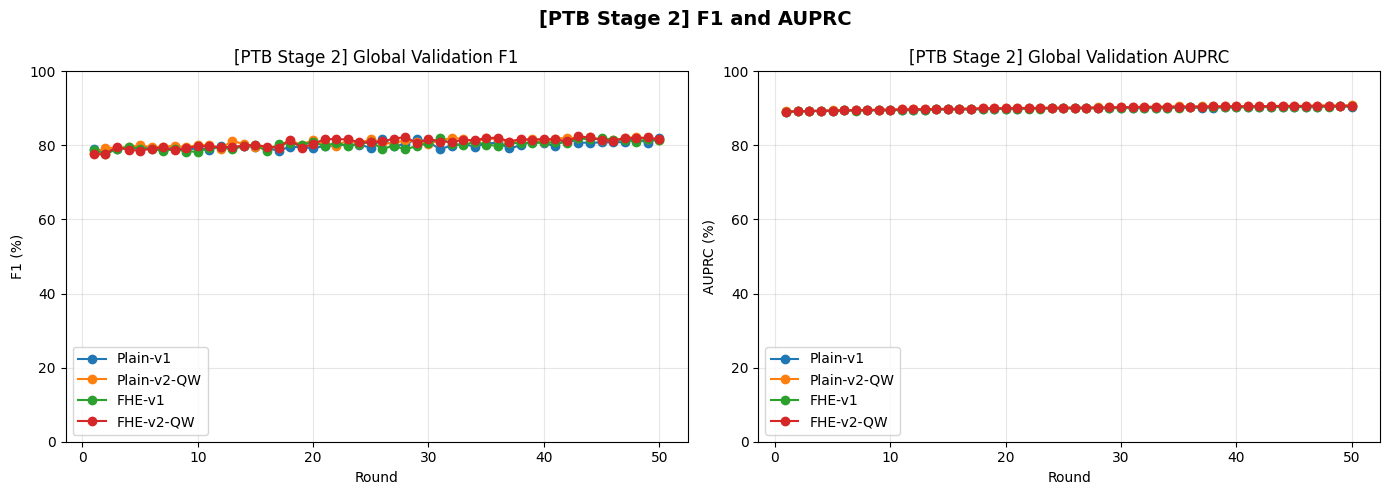

In [86]:
# PTB Stage 2 - Global Validation F1 and AUPRC

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def _find_metric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_stage2_f1_auprc_together(
    results_dict,
    title_prefix="[PTB Stage 2]"
):
    metric_specs = [
        (["val_f1", "ValF1"], "Global Validation F1", "F1 (%)"),
        (["val_auprc", "ValAUPRC", "val_auprc_percent"], "Global Validation AUPRC", "AUPRC (%)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title_prefix} F1 and AUPRC", fontsize=14, fontweight="bold")

    for ax, (candidates, subtitle, ylabel) in zip(axes, metric_specs):
        plotted = False

        for name, result in results_dict.items():
            df = pd.DataFrame(result["history"])

            if "round" in df.columns:
                x = df["round"].values
            else:
                x = np.arange(1, len(df) + 1)

            metric_col = _find_metric_col(df, candidates)

            if metric_col is None:
                print(f"⚠️ {name}: metric not found from {candidates}")
                continue

            ax.plot(
                x,
                df[metric_col].values,
                marker="o",
                label=name
            )
            plotted = True

        ax.set_title(f"{title_prefix} {subtitle}")
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.3)

        if plotted:
            ax.legend()
        else:
            ax.text(
                0.5, 0.5,
                "Metric not found",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

    plt.tight_layout()
    plt.show()


plot_stage2_f1_auprc_together(
    results_stage2,
    title_prefix="[PTB Stage 2]"
)

✅ Figure saved to: PTB_CKKS_VS_PAILLIER_TIME_LOG.png


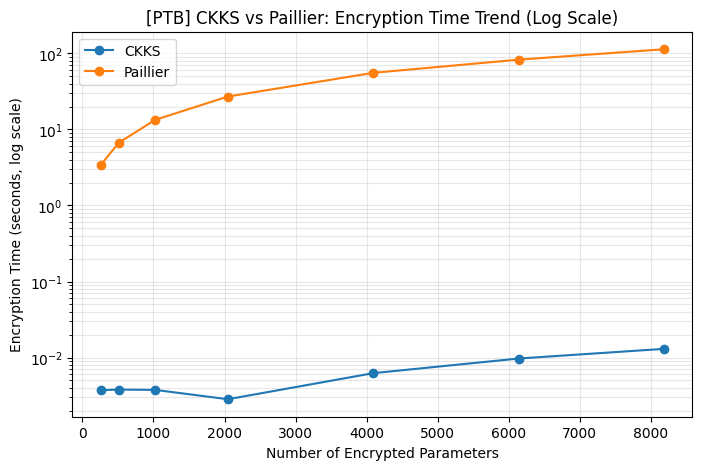

In [169]:
# PTB - CKKS vs Paillier Encryption Time Trend (Log Scale)

plot_ckks_vs_paillier_time_log(
    benchmark_df=encryption_comm_benchmark_df,
    title="[PTB] CKKS vs Paillier: Encryption Time Trend (Log Scale)",
    save_path="PTB_CKKS_VS_PAILLIER_TIME_LOG.png"
)

In [54]:
def local_stage2_train_fedprox_ptb(
    model,
    train_loader,
    global_backbone_sd,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    fedprox_mu=0.01,
):
    model = model.to(device)
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if class_weights is not None:
        class_weights = class_weights.to(device)

    global_ref = {
        k: v.detach().to(device)
        for k, v in global_backbone_sd.items()
    }

    init_backbone = get_backbone_state(model)

    running_loss = 0.0
    n_batches = 0

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            ce_loss = F.cross_entropy(logits, y, weight=class_weights)

            prox_loss = 0.0
            for name, param in model.backbone.named_parameters():
                if name in global_ref:
                    prox_loss = prox_loss + torch.sum(
                        (param - global_ref[name]) ** 2
                    )

            loss = ce_loss + 0.5 * fedprox_mu * prox_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

    new_backbone = get_backbone_state(model)
    head_state = get_head_state(model)

    delta_backbone = {}
    for k in init_backbone:
        delta_backbone[k] = new_backbone[k] - init_backbone[k]

    mean_loss = running_loss / max(n_batches, 1)

    return {
        "model": model,
        "delta_backbone": delta_backbone,
        "head_state": head_state,
        "train_loss": mean_loss,
    }

print("✅ PTB FedProx local training ready.")

✅ PTB FedProx local training ready.


In [55]:
def backbone_delta_l2_norm_ptb(delta_sd):
    total = 0.0
    for v in delta_sd.values():
        total += torch.sum(v.detach().float().cpu() ** 2).item()
    return float(np.sqrt(total))


def clip_backbone_delta_ptb(delta_sd, max_norm=1.0):
    raw_norm = backbone_delta_l2_norm_ptb(delta_sd)
    clip_coef = min(1.0, max_norm / (raw_norm + 1e-12))

    clipped = {}
    for k, v in delta_sd.items():
        clipped[k] = v.detach().cpu() * clip_coef

    return clipped, raw_norm, clip_coef


def add_gaussian_noise_to_delta_ptb(avg_delta, noise_std):
    if noise_std is None or noise_std <= 0:
        return avg_delta

    noisy = {}

    for k, v in avg_delta.items():
        noisy[k] = v.detach().cpu() + torch.normal(
            mean=0.0,
            std=float(noise_std),
            size=v.shape
        )

    return noisy

print("✅ PTB DP helper ready.")

✅ PTB DP helper ready.


In [56]:
def stage2_train_fhe_baseline_ptb(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=30,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,

    method="dp_fedavg",      # "dp_fedavg" or "fedprox"
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    fedprox_mu=0.01,

    he_poly_modulus_degree=8192,
    he_coeff_mod_bit_sizes=[60, 40, 40, 60],
    he_global_scale=2**40,
    he_chunk_size=2048,
    verbose_he=True,

    run_name="PTB-STAGE2-FHE-BASELINE",
):
    assert method in ["dp_fedavg", "fedprox"]

    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device,
    )

    client_models, client_head_key_map = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders),
        num_classes=num_classes,
        device=device,
    )

    global_backbone = get_backbone_state(global_model)
    history = []

    he_backend = TenSEALCKKSBackend(
        poly_modulus_degree=he_poly_modulus_degree,
        coeff_mod_bit_sizes=he_coeff_mod_bit_sizes,
        global_scale=he_global_scale,
        chunk_size=he_chunk_size,
        verbose=verbose_he,
    )

    for rnd in range(1, num_rounds + 1):
        print(f"[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_losses = []
        raw_delta_norms = []
        clip_coefs = []

        for cid in range(len(client_loaders)):
            load_backbone_state(client_models[cid], global_backbone)

            if method == "fedprox":
                out = local_stage2_train_fedprox_ptb(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    global_backbone_sd=global_backbone,
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                    fedprox_mu=fedprox_mu,
                )
            else:
                out = local_stage2_train(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                )

            client_models[cid] = out["model"]

            delta = out["delta_backbone"]

            if method == "dp_fedavg":
                delta, raw_norm, clip_coef = clip_backbone_delta_ptb(
                    delta,
                    max_norm=dp_clip_norm
                )
                raw_delta_norms.append(raw_norm)
                clip_coefs.append(clip_coef)

            local_deltas.append(delta)
            local_losses.append(out["train_loss"])

        # FHE-FedAvg aggregation
        weights = None
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device="cpu"
        )

        if method == "dp_fedavg":
            dp_noise_std = float(dp_noise_multiplier * dp_clip_norm / len(client_loaders))
            avg_delta = add_gaussian_noise_to_delta_ptb(
                avg_delta,
                noise_std=dp_noise_std
            )
        else:
            dp_noise_std = 0.0

        global_backbone = apply_backbone_delta(global_backbone, avg_delta)
        load_backbone_state(global_model, global_backbone)

        val_metrics = evaluate_model(
            global_model,
            global_val_loader,
            device=device
        )

        test_metrics = evaluate_model(
            global_model,
            global_test_loader,
            device=device
        )

        personal_metrics = []
        for cid in range(len(client_models)):
            load_backbone_state(client_models[cid], global_backbone)
            m = evaluate_model(
                client_models[cid],
                client_val_loaders[cid],
                device=device
            )
            personal_metrics.append(m)

        mean_personal_acc = float(np.mean([m["acc"] for m in personal_metrics]))
        mean_personal_balacc = float(np.mean([m["bal_acc"] for m in personal_metrics]))
        mean_local_loss = float(np.mean(local_losses))

        print(
            f"[{run_name}][Round {rnd}] "
            f"LocalLoss={mean_local_loss:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={mean_personal_acc:.2f}% | "
            f"PersonalBalAcc={mean_personal_balacc:.2f}% | "
            f"HE(enc={he_stats['encrypt_time_sec']:.6f}s, "
            f"agg={he_stats['aggregate_time_sec']:.6f}s, "
            f"dec={he_stats['decrypt_time_sec']:.6f}s)"
        )

        history.append({
            "round": rnd,
            "local_loss": mean_local_loss,

            "val_acc": val_metrics["acc"],
            "val_bal_acc": val_metrics["bal_acc"],
            "val_f1": val_metrics["f1"],
            "val_auprc": val_metrics["auprc"],

            "test_acc": test_metrics["acc"],
            "test_bal_acc": test_metrics["bal_acc"],
            "test_f1": test_metrics["f1"],
            "test_auprc": test_metrics["auprc"],

            "personal_acc": mean_personal_acc,
            "personal_bal_acc": mean_personal_balacc,

            "method": method,
            "dp_clip_norm": float(dp_clip_norm) if method == "dp_fedavg" else None,
            "dp_noise_multiplier": float(dp_noise_multiplier) if method == "dp_fedavg" else None,
            "dp_noise_std": float(dp_noise_std) if method == "dp_fedavg" else None,
            "delta_norm_mean_preclip": float(np.mean(raw_delta_norms)) if raw_delta_norms else None,
            "clip_hit_rate": float(np.mean(np.array(clip_coefs) < 1.0)) if clip_coefs else None,
            "fedprox_mu": float(fedprox_mu) if method == "fedprox" else None,

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],
        })

    return {
        "global_model": global_model,
        "client_models": client_models,
        "global_backbone": global_backbone,
        "client_head_key_map": client_head_key_map,
        "history": history,
        "method": method,
        "run_name": run_name,
    }

print("✅ stage2_train_fhe_baseline_ptb ready.")

✅ stage2_train_fhe_baseline_ptb ready.


In [96]:
result_ptb_stage2_fhe_dp_fedavg = stage2_train_fhe_baseline_ptb(
    client_loaders=good_client_loaders,
    client_val_loaders=good_client_val_loaders,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_align_filtered,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=None,
    num_classes=NUM_CLASSES,
    method="dp_fedavg",
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    run_name="PTB-STAGE2-FHE-DP-FEDAVG",
)

torch.save(
    result_ptb_stage2_fhe_dp_fedavg,
    "PTB_STAGE2_FHE_DP_FEDAVG.pt"
)


result_ptb_stage2_fhe_fedprox = stage2_train_fhe_baseline_ptb(
    client_loaders=good_client_loaders,
    client_val_loaders=good_client_val_loaders,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_align_filtered,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=None,
    num_classes=NUM_CLASSES,
    method="fedprox",
    fedprox_mu=0.01,
    run_name="PTB-STAGE2-FHE-FEDPROX",
)

torch.save(
    result_ptb_stage2_fhe_fedprox,
    "PTB_STAGE2_FHE_FEDPROX.pt"
)

✅ HE backend ready | scheme=CKKS | poly_modulus_degree=8192 | coeff_mod_bit_sizes=[60, 40, 40, 60] | global_scale=1099511627776 | chunk_size=2048
[PTB-STAGE2-FHE-DP-FEDAVG] Round 1/50
[PTB-STAGE2-FHE-DP-FEDAVG][Round 1] LocalLoss=0.3795 | ValAcc=75.54% | ValBalAcc=76.46% | ValF1=76.72% | ValAUPRC=89.03% | PersonalAcc=82.10% | PersonalBalAcc=69.23% | HE(enc=0.291549s, agg=0.002801s, dec=0.007956s)
[PTB-STAGE2-FHE-DP-FEDAVG] Round 2/50
[PTB-STAGE2-FHE-DP-FEDAVG][Round 2] LocalLoss=0.3873 | ValAcc=76.47% | ValBalAcc=77.02% | ValF1=78.15% | ValAUPRC=89.24% | PersonalAcc=82.35% | PersonalBalAcc=69.50% | HE(enc=0.354934s, agg=0.002154s, dec=0.008099s)
[PTB-STAGE2-FHE-DP-FEDAVG] Round 3/50
[PTB-STAGE2-FHE-DP-FEDAVG][Round 3] LocalLoss=0.3696 | ValAcc=75.91% | ValBalAcc=76.53% | ValF1=77.51% | ValAUPRC=89.09% | PersonalAcc=82.32% | PersonalBalAcc=68.95% | HE(enc=0.288701s, agg=0.002328s, dec=0.008017s)
[PTB-STAGE2-FHE-DP-FEDAVG] Round 4/50
[PTB-STAGE2-FHE-DP-FEDAVG][Round 4] LocalLoss=0.3837 |